# Exploratory Data Analysis

---

| Item | Detail |
|------|--------|
| **Dataset** | `Data_Klaim.csv` — 4,627 paid claims (Jan 2024 – Jul 2025) |
| **Purpose** | Uncover patterns, seasonality, outliers & structural signals |

**Sections**
1. Setup & Data Overview  
2. Time Series — Frequency, Severity & Total Claim  
3. Seasonality & Calendar Patterns  
4. Claim Distribution & Concentration  
5. Claim Type Analysis (Inpatient / Outpatient / Cashless / Reimburse)  
6. Geographic Analysis (Hospital Location)  
7. Diagnosis Analysis (ICD Codes)  
8. Severity Drivers & Outlier Detection  
9. Year-over-Year Comparison  
10. Key Takeaways for Prediction

---
## 1. Setup & Data Overview

In [42]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates

# ── Colour palette ────────────────────────────────────────────────────────────
C = dict(
    freq   = '#2196F3',   # blue
    sev    = '#FF9800',   # orange
    total  = '#4CAF50',   # green
    accent = '#E91E63',   # pink / highlight
    neutral= '#78909C',   # grey
    ip     = '#3F51B5',
    op     = '#009688',
    r      = '#FF5722',
    c      = '#8BC34A',
)

plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.30,
    'grid.linestyle'   : '--',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'legend.framealpha': 0.85,
})

DATA_DIR   = Path('data')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUTPUT_DIR / f'{name}.png', bbox_inches='tight', dpi=150)

print('Setup complete.')

Setup complete.


In [43]:
# ── Load ──────────────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_DIR / 'Data_Klaim.csv')

# ── Type casting ──────────────────────────────────────────────────────────────
raw['admission_date'] = pd.to_datetime(raw['Tanggal Pasien Masuk RS'])
raw['discharge_date'] = pd.to_datetime(raw['Tanggal Pasien Keluar RS'])
raw['payment_date']   = pd.to_datetime(raw['Tanggal Pembayaran Klaim'], errors='coerce')
raw['approved_claim'] = raw['Nominal Klaim Yang Disetujui']
raw['hospital_cost']  = raw['Nominal Biaya RS Yang Terjadi']

# ── Derived fields ────────────────────────────────────────────────────────────
raw['year']      = raw['admission_date'].dt.year
raw['month']     = raw['admission_date'].dt.month
raw['week']      = raw['admission_date'].dt.isocalendar().week.astype(int)
raw['dayofweek'] = raw['admission_date'].dt.day_name()
raw['ym']        = list(zip(raw['year'], raw['month']))
raw['period']    = raw['admission_date'].dt.to_period('W')
raw['los']       = (raw['discharge_date'] - raw['admission_date']).dt.days
raw['icd3']      = raw['ICD Diagnosis'].str[:3]
raw['claim_type']= raw['Inpatient/Outpatient'].fillna('Unknown')
raw['channel']   = raw['Reimburse/Cashless'].map({'R': 'Reimburse', 'C': 'Cashless'})
raw['location']  = raw['Lokasi RS'].fillna('Unknown')

df = raw.copy()
print(f'Total claims : {len(df):,}')
print(f'Date range   : {df["admission_date"].min().date()}  →  {df["admission_date"].max().date()}')
print(f'Unique polis : {df["Nomor Polis"].nunique():,}')
print(f'Total amount : IDR {df["approved_claim"].sum() / 1e12:.2f} Trillion')
df.head(3)

Total claims : 4,627
Date range   : 2024-01-01  →  2025-07-31
Unique polis : 1,210
Total amount : IDR 0.25 Trillion


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,...,month,week,dayofweek,ym,period,los,icd3,claim_type,channel,location
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,...,5,22,Monday,"(2024, 5)",2024-05-27/2024-06-02,0,C50,OP,Reimburse,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,...,7,29,Monday,"(2024, 7)",2024-07-15/2024-07-21,0,C34,OP,Reimburse,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,...,5,20,Thursday,"(2024, 5)",2024-05-13/2024-05-19,0,C18,OP,Reimburse,Singapore


In [44]:
# ── Build monthly & weekly aggregates ─────────────────────────────────────────
monthly = (
    df.groupby('ym')
    .agg(frequency=('Claim ID','count'), total_claim=('approved_claim','sum'))
    .reset_index()
)
monthly['severity'] = monthly['total_claim'] / monthly['frequency']
monthly['date']     = monthly['ym'].apply(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))
monthly             = monthly.sort_values('date').reset_index(drop=True)

weekly = (
    df.groupby('period')
    .agg(frequency=('Claim ID','count'), total_claim=('approved_claim','sum'))
    .reset_index()
)
weekly['ws']      = weekly['period'].dt.start_time.dt.normalize()
weekly['severity']= weekly['total_claim'] / weekly['frequency']
weekly            = weekly.sort_values('ws').reset_index(drop=True)

print(f'Monthly rows : {len(monthly)} | Weekly rows : {len(weekly)}')

Monthly rows : 19 | Weekly rows : 83


---
## 2. Time Series — Frequency, Severity & Total Claim
> **Prediction insight:** Understand trend direction and volatility for each target variable.

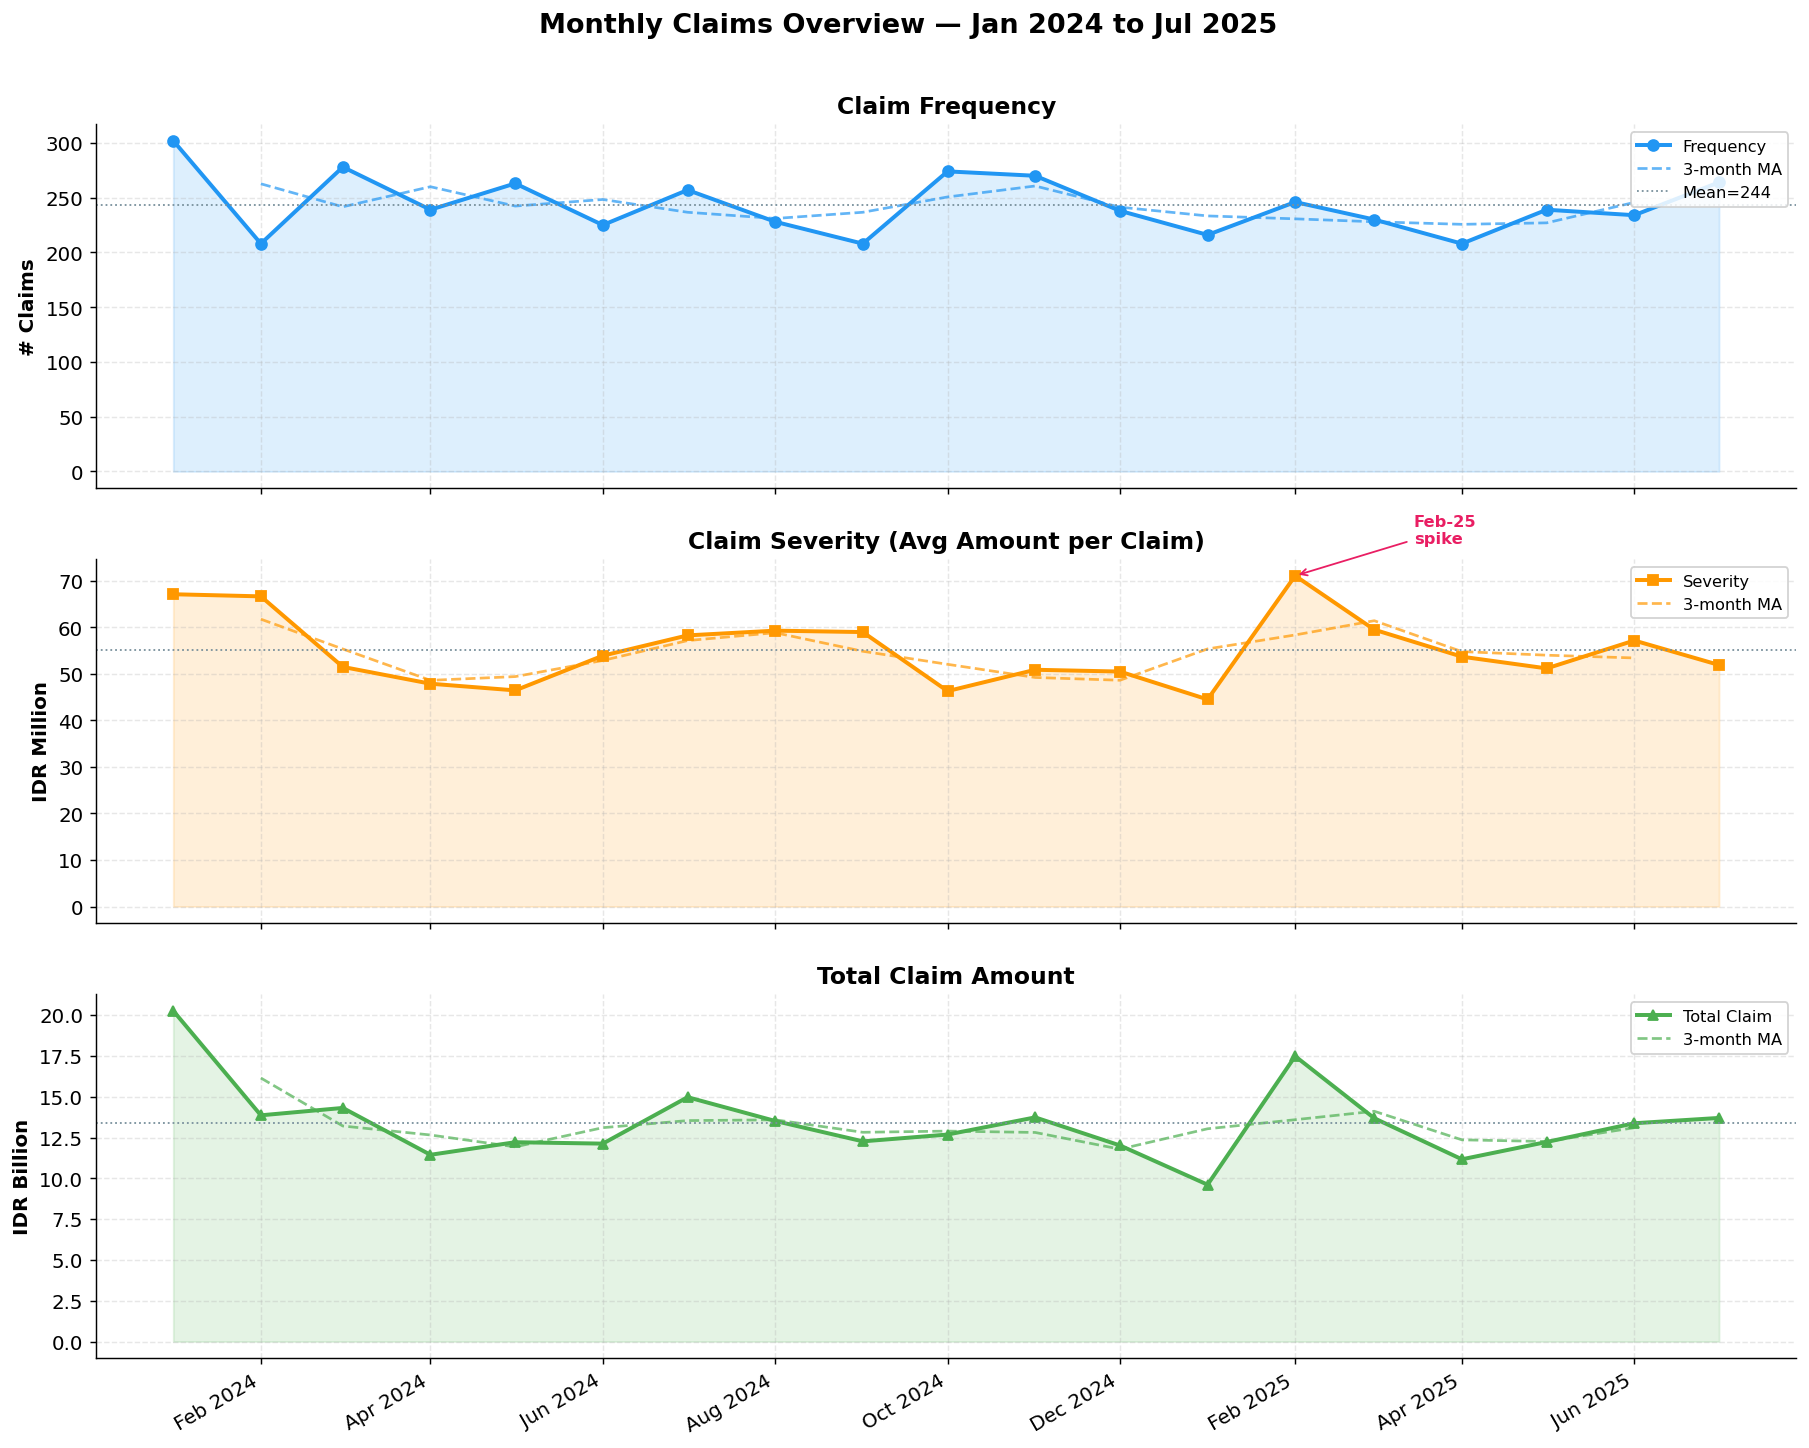


── Descriptive Statistics (Monthly) ──


,Frequency,Severity (IDR),Total Claim (IDR)
count,19,19,19
mean,244,"55,073,532","13,400,991,240"
std,27,"7,440,240","2,343,592,146"
min,208,"44,492,499","9,610,379,679"
25%,226,"50,670,896","12,168,314,500"
50%,239,"53,674,271","13,373,119,879"
75%,264,"59,114,687","13,796,352,469"
max,302,"71,059,107","20,260,981,490"


In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Monthly Claims Overview — Jan 2024 to Jul 2025', fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Frequency ────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(monthly['date'], monthly['frequency'], alpha=0.15, color=C['freq'])
ax.plot(monthly['date'], monthly['frequency'], marker='o', color=C['freq'], lw=2.2, label='Frequency')
# Rolling mean
rm = monthly['frequency'].rolling(3, center=True).mean()
ax.plot(monthly['date'], rm, color=C['freq'], lw=1.5, linestyle='--', alpha=0.7, label='3-month MA')
ax.axhline(monthly['frequency'].mean(), color=C['neutral'], lw=1, linestyle=':', label=f'Mean={monthly["frequency"].mean():.0f}')
ax.set_ylabel('# Claims', fontweight='bold')
ax.set_title('Claim Frequency')
ax.legend(loc='upper right', fontsize=9)

# ── Panel 2: Severity ─────────────────────────────────────────────────────────
ax = axes[1]
ax.fill_between(monthly['date'], monthly['severity'] / 1e6, alpha=0.15, color=C['sev'])
ax.plot(monthly['date'], monthly['severity'] / 1e6, marker='s', color=C['sev'], lw=2.2, label='Severity')
rm2 = monthly['severity'].rolling(3, center=True).mean() / 1e6
ax.plot(monthly['date'], rm2, color=C['sev'], lw=1.5, linestyle='--', alpha=0.7, label='3-month MA')
ax.axhline(monthly['severity'].mean() / 1e6, color=C['neutral'], lw=1, linestyle=':')
# Highlight Feb 2025 spike
feb25 = monthly[monthly['ym'] == (2025, 2)]
ax.annotate('Feb-25\nspike', xy=(feb25['date'].values[0], feb25['severity'].values[0]/1e6),
            xytext=(pd.Timestamp('2025-03-15'), 78),
            arrowprops=dict(arrowstyle='->', color=C['accent']),
            color=C['accent'], fontsize=9, fontweight='bold')
ax.set_ylabel('IDR Million', fontweight='bold')
ax.set_title('Claim Severity (Avg Amount per Claim)')
ax.legend(loc='upper right', fontsize=9)

# ── Panel 3: Total Claim ──────────────────────────────────────────────────────
ax = axes[2]
ax.fill_between(monthly['date'], monthly['total_claim'] / 1e9, alpha=0.15, color=C['total'])
ax.plot(monthly['date'], monthly['total_claim'] / 1e9, marker='^', color=C['total'], lw=2.2, label='Total Claim')
rm3 = monthly['total_claim'].rolling(3, center=True).mean() / 1e9
ax.plot(monthly['date'], rm3, color=C['total'], lw=1.5, linestyle='--', alpha=0.7, label='3-month MA')
ax.axhline(monthly['total_claim'].mean() / 1e9, color=C['neutral'], lw=1, linestyle=':')
ax.set_ylabel('IDR Billion', fontweight='bold')
ax.set_title('Total Claim Amount')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
savefig('eda_01_monthly_timeseries')
plt.show()

print('\n── Descriptive Statistics (Monthly) ──')
display(monthly[['frequency','severity','total_claim']]
        .rename(columns={'frequency':'Frequency','severity':'Severity (IDR)','total_claim':'Total Claim (IDR)'})
        .describe().applymap(lambda x: f'{x:,.0f}'))

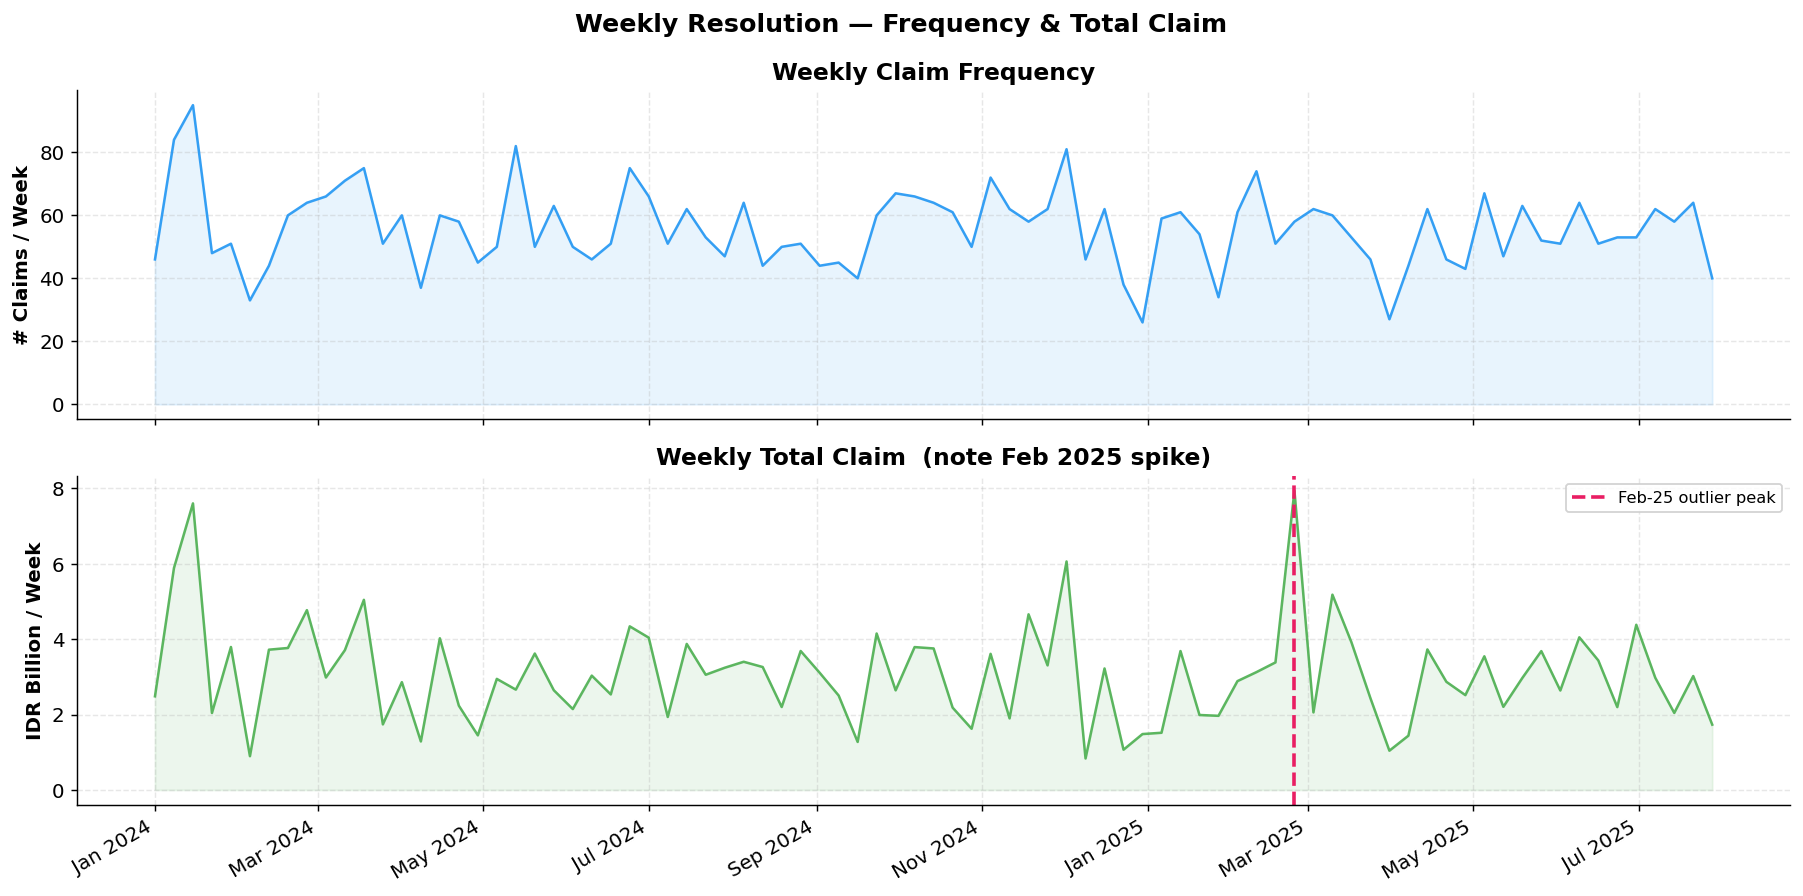

In [46]:
# ── Weekly series (higher resolution) ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Weekly Resolution — Frequency & Total Claim', fontsize=14, fontweight='bold')

axes[0].plot(weekly['ws'], weekly['frequency'], color=C['freq'], lw=1.4, alpha=0.9)
axes[0].fill_between(weekly['ws'], weekly['frequency'], alpha=0.1, color=C['freq'])
axes[0].set_ylabel('# Claims / Week', fontweight='bold')
axes[0].set_title('Weekly Claim Frequency')

axes[1].plot(weekly['ws'], weekly['total_claim'] / 1e9, color=C['total'], lw=1.4, alpha=0.9)
axes[1].fill_between(weekly['ws'], weekly['total_claim'] / 1e9, alpha=0.1, color=C['total'])
axes[1].set_ylabel('IDR Billion / Week', fontweight='bold')
axes[1].set_title('Weekly Total Claim  (note Feb 2025 spike)')

# Mark Feb 2025 outlier week
feb_peak = weekly.nlargest(1, 'total_claim')
axes[1].axvline(feb_peak['ws'].values[0], color=C['accent'], lw=2, linestyle='--', label='Feb-25 outlier peak')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
savefig('eda_02_weekly_timeseries')
plt.show()

---
## 3. Seasonality & Calendar Patterns
> **Prediction insight:** Month-of-year and day-of-week patterns that repeat in Aug–Dec 2025.

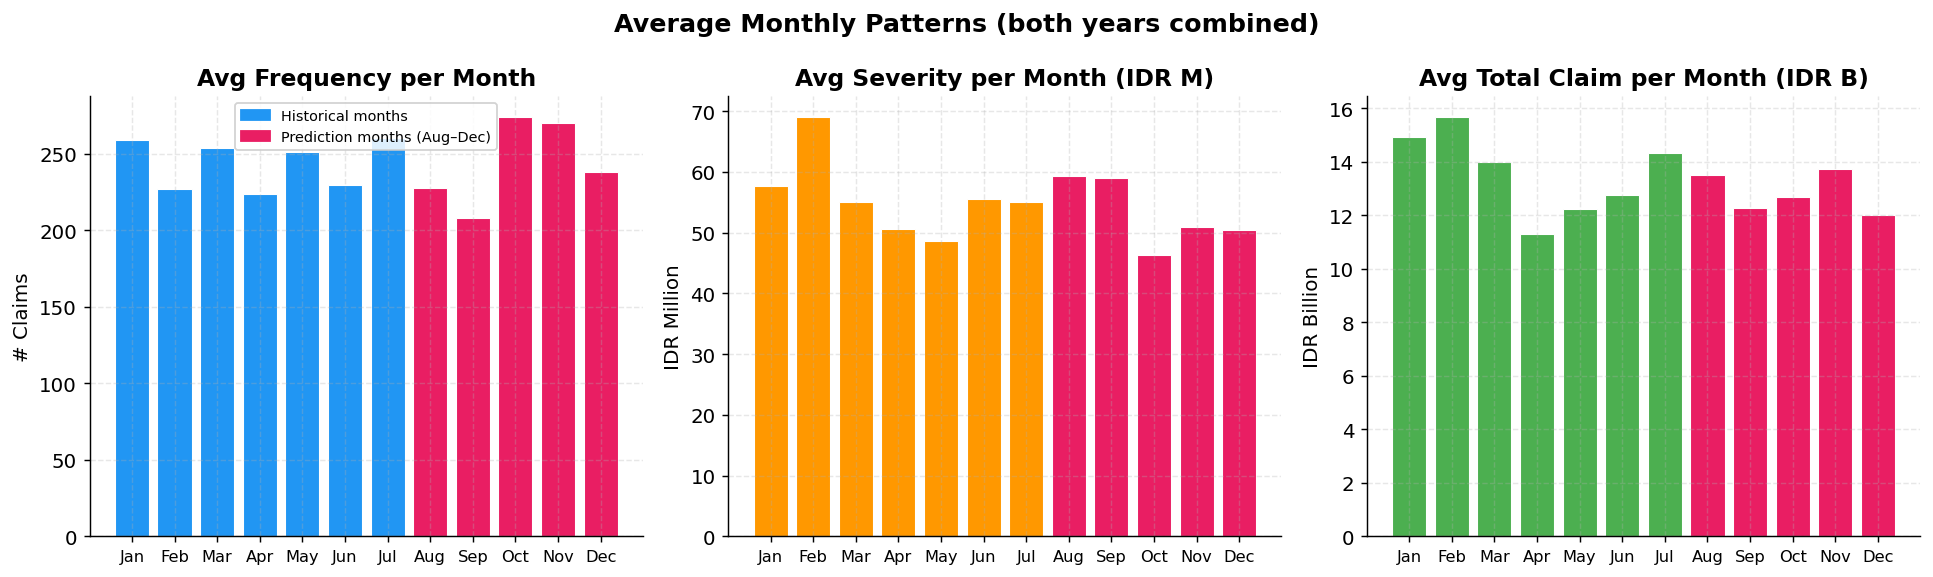

In [47]:
# ── Month-of-year patterns ────────────────────────────────────────────────────
by_month = df.groupby('month').agg(
    frequency=('Claim ID', 'count'),
    total_claim=('approved_claim', 'sum')
).reset_index()
by_month['severity']  = by_month['total_claim'] / by_month['frequency']
# Normalise by number of years observed for each month
months_in_data = df.groupby('month')['year'].nunique()
by_month['freq_avg']  = by_month.apply(lambda r: r['frequency'] / months_in_data[r['month']], axis=1)
by_month['tot_avg']   = by_month.apply(lambda r: r['total_claim'] / months_in_data[r['month']], axis=1)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
by_month['month_name'] = by_month['month'].apply(lambda m: month_names[m-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Average Monthly Patterns (both years combined)', fontsize=14, fontweight='bold')

bar_colors_freq = [C['accent'] if m in [8,9,10,11,12] else C['freq'] for m in by_month['month']]
bar_colors_sev  = [C['accent'] if m in [8,9,10,11,12] else C['sev']  for m in by_month['month']]
bar_colors_tot  = [C['accent'] if m in [8,9,10,11,12] else C['total']for m in by_month['month']]

axes[0].bar(by_month['month_name'], by_month['freq_avg'], color=bar_colors_freq, edgecolor='white', linewidth=0.6)
axes[0].set_title('Avg Frequency per Month')
axes[0].set_ylabel('# Claims')

axes[1].bar(by_month['month_name'], by_month['severity'] / 1e6, color=bar_colors_sev, edgecolor='white', linewidth=0.6)
axes[1].set_title('Avg Severity per Month (IDR M)')
axes[1].set_ylabel('IDR Million')

axes[2].bar(by_month['month_name'], by_month['tot_avg'] / 1e9, color=bar_colors_tot, edgecolor='white', linewidth=0.6)
axes[2].set_title('Avg Total Claim per Month (IDR B)')
axes[2].set_ylabel('IDR Billion')

for ax in axes:
    ax.tick_params(axis='x', labelsize=9)

# Legend
pred_patch  = mpatches.Patch(color=C['accent'],  label='Prediction months (Aug–Dec)')
hist_patch  = mpatches.Patch(color=C['freq'],    label='Historical months')
axes[0].legend(handles=[hist_patch, pred_patch], fontsize=8)

plt.tight_layout()
savefig('eda_03_monthly_seasonality')
plt.show()

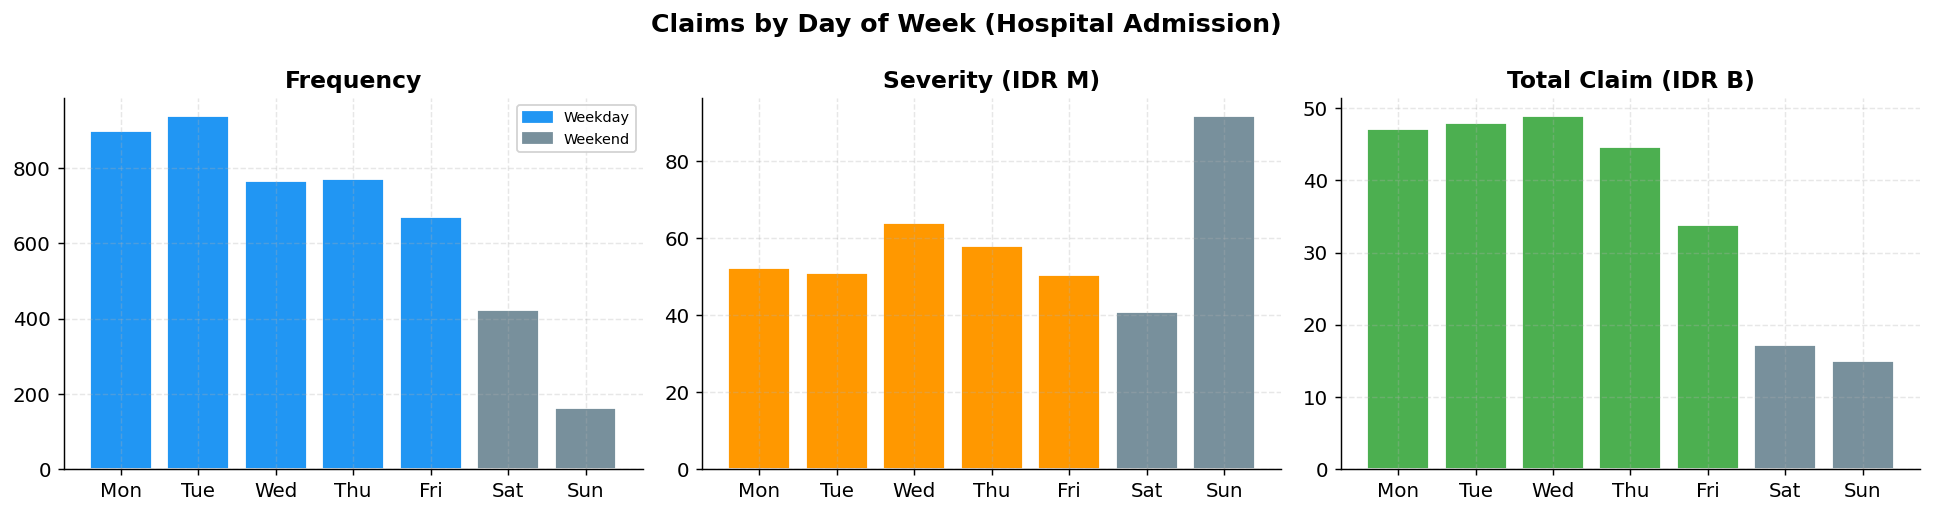

Avg weekday frequency : 808 | Avg weekend frequency : 294
Weekend / Weekday ratio: 0.36


In [48]:
# ── Day-of-week pattern ───────────────────────────────────────────────────────
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_dow = df.groupby('dayofweek').agg(
    frequency=('Claim ID','count'),
    total_claim=('approved_claim','sum')
).reindex(DOW_ORDER).reset_index()
by_dow['severity'] = by_dow['total_claim'] / by_dow['frequency']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Claims by Day of Week (Hospital Admission)', fontsize=14, fontweight='bold')

weekend_colors = [C['neutral'] if d in ['Saturday','Sunday'] else C['freq'] for d in by_dow['dayofweek']]
weekend_sev    = [C['neutral'] if d in ['Saturday','Sunday'] else C['sev']  for d in by_dow['dayofweek']]
weekend_tot    = [C['neutral'] if d in ['Saturday','Sunday'] else C['total']for d in by_dow['dayofweek']]

for ax, col, colors, unit, title in zip(
    axes,
    ['frequency', 'severity', 'total_claim'],
    [weekend_colors, weekend_sev, weekend_tot],
    [1, 1e6, 1e9],
    ['Frequency', 'Severity (IDR M)', 'Total Claim (IDR B)']
):
    vals = by_dow[col] / unit
    ax.bar([d[:3] for d in by_dow['dayofweek']], vals, color=colors, edgecolor='white')
    ax.set_title(title)

axes[0].legend(handles=[
    mpatches.Patch(color=C['freq'],    label='Weekday'),
    mpatches.Patch(color=C['neutral'], label='Weekend'),
], fontsize=8)

plt.tight_layout()
savefig('eda_04_dayofweek')
plt.show()

weekday_freq = by_dow[~by_dow['dayofweek'].isin(['Saturday','Sunday'])]['frequency'].mean()
weekend_freq = by_dow[ by_dow['dayofweek'].isin(['Saturday','Sunday'])]['frequency'].mean()
print(f'Avg weekday frequency : {weekday_freq:.0f} | Avg weekend frequency : {weekend_freq:.0f}')
print(f'Weekend / Weekday ratio: {weekend_freq/weekday_freq:.2f}')

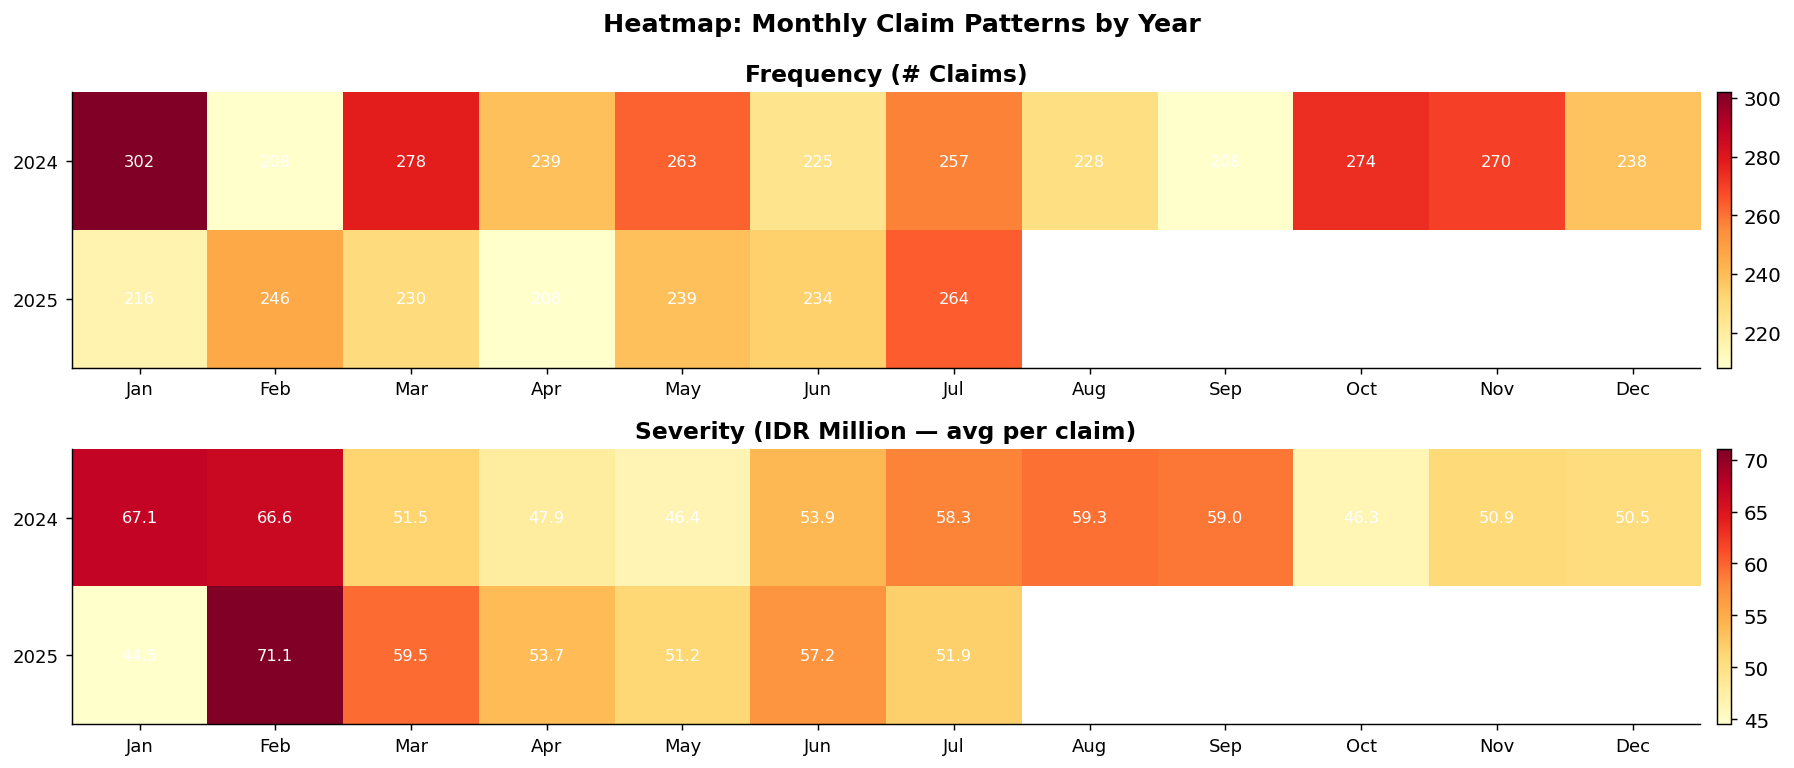

In [49]:
# ── Heatmap: frequency by year × month ───────────────────────────────────────
pivot_freq = df.pivot_table(index='year', columns='month', values='Claim ID', aggfunc='count')
pivot_freq.columns = [month_names[m-1] for m in pivot_freq.columns]

pivot_sev  = df.pivot_table(index='year', columns='month', values='approved_claim', aggfunc='mean')
pivot_sev.columns = [month_names[m-1] for m in pivot_sev.columns]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle('Heatmap: Monthly Claim Patterns by Year', fontsize=14, fontweight='bold')

for ax, pivot, title, fmt in zip(
    axes,
    [pivot_freq, pivot_sev / 1e6],
    ['Frequency (# Claims)', 'Severity (IDR Million — avg per claim)'],
    ['.0f', '.1f']
):
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    ax.set_title(title)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
    # Annotate cells
    for i in range(pivot.values.shape[0]):
        for j in range(pivot.values.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:{fmt}}', ha='center', va='center',
                        fontsize=9, color='black' if v < pivot.values.max()*0.7 else 'white')

plt.tight_layout()
savefig('eda_05_heatmap_yearmonth')
plt.show()

---
## 4. Claim Distribution & Concentration
> **Prediction insight:** Heavy tails mean a few large claims dominate Total Claim — outlier handling is critical.

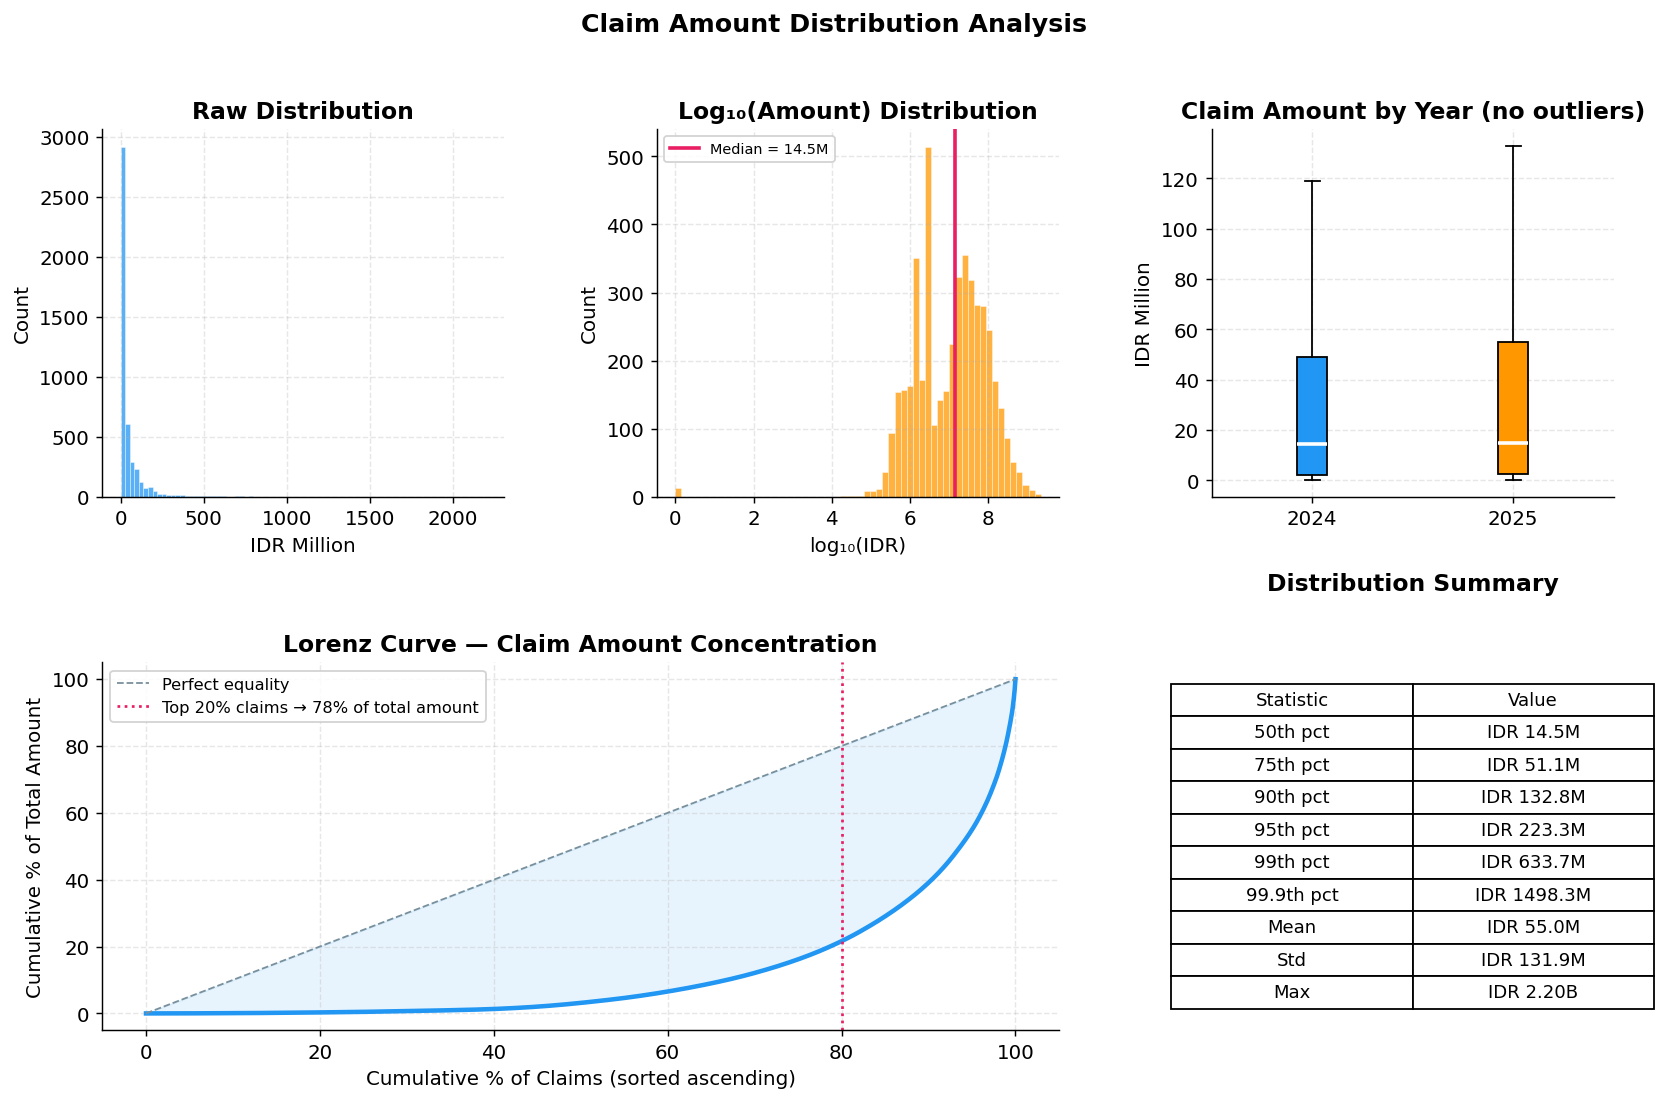

⚠  Top 10% of claims account for 60.9% of total paid amount
   → Severity is highly sensitive to large outlier claims


In [50]:
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Claim Amount Distribution Analysis', fontsize=14, fontweight='bold')

amounts = df['approved_claim'].values

# ── Raw histogram ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(amounts / 1e6, bins=80, color=C['freq'], alpha=0.75, edgecolor='white', linewidth=0.3)
ax1.set_title('Raw Distribution')
ax1.set_xlabel('IDR Million')
ax1.set_ylabel('Count')

# ── Log-scale histogram ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
log_amounts = np.log10(np.maximum(amounts, 1))
ax2.hist(log_amounts, bins=60, color=C['sev'], alpha=0.75, edgecolor='white', linewidth=0.3)
ax2.set_title('Log₁₀(Amount) Distribution')
ax2.set_xlabel('log₁₀(IDR)')
ax2.set_ylabel('Count')
ax2.axvline(np.median(log_amounts), color=C['accent'], lw=2, label=f'Median = {10**np.median(log_amounts)/1e6:.1f}M')
ax2.legend(fontsize=8)

# ── Box plot by year ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
data_by_year = [df[df['year']==y]['approved_claim'].values / 1e6 for y in [2024, 2025]]
bp = ax3.boxplot(data_by_year, labels=['2024','2025'], patch_artist=True,
                  medianprops=dict(color='white', lw=2), showfliers=False)
bp['boxes'][0].set_facecolor(C['freq'])
bp['boxes'][1].set_facecolor(C['sev'])
ax3.set_title('Claim Amount by Year (no outliers)')
ax3.set_ylabel('IDR Million')

# ── Lorenz / Pareto curve ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
sorted_amounts = np.sort(amounts)
cumulative_pct = np.cumsum(sorted_amounts) / sorted_amounts.sum() * 100
claim_pct      = np.arange(1, len(sorted_amounts)+1) / len(sorted_amounts) * 100
ax4.plot(claim_pct, cumulative_pct, color=C['freq'], lw=2.5)
ax4.plot([0, 100], [0, 100], color=C['neutral'], lw=1, linestyle='--', label='Perfect equality')
# Find 20%-80%
idx20 = int(0.20 * len(sorted_amounts))
idx80 = int(0.80 * len(sorted_amounts))
pct_top20_holds = 100 - cumulative_pct[idx80]
pct_bot80_holds = cumulative_pct[idx80]
ax4.axvline(80, color=C['accent'], lw=1.5, linestyle=':', label=f'Top 20% claims → {pct_top20_holds:.0f}% of total amount')
ax4.fill_between(claim_pct, cumulative_pct, claim_pct, alpha=0.10, color=C['freq'])
ax4.set_title('Lorenz Curve — Claim Amount Concentration')
ax4.set_xlabel('Cumulative % of Claims (sorted ascending)')
ax4.set_ylabel('Cumulative % of Total Amount')
ax4.legend(fontsize=9)

# ── Percentile table ──────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
pcts = [50, 75, 90, 95, 99, 99.9]
vals = np.percentile(amounts, pcts)
table_data = [[f'{p}th pct', f'IDR {v/1e6:.1f}M'] for p, v in zip(pcts, vals)]
table_data += [['Mean', f'IDR {amounts.mean()/1e6:.1f}M'],
               ['Std',  f'IDR {amounts.std()/1e6:.1f}M'],
               ['Max',  f'IDR {amounts.max()/1e9:.2f}B']]
tbl = ax5.table(cellText=table_data, colLabels=['Statistic','Value'],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
ax5.set_title('Distribution Summary', fontweight='bold', pad=40)

savefig('eda_06_distribution')
plt.show()

top10_pct = (df.nlargest(int(len(df)*0.10), 'approved_claim')['approved_claim'].sum()
             / df['approved_claim'].sum() * 100)
print(f'⚠  Top 10% of claims account for {top10_pct:.1f}% of total paid amount')
print(f'   → Severity is highly sensitive to large outlier claims')

---
## 5. Claim Type Analysis
> **Prediction insight:** IP/OP ratio and Reimburse/Cashless mix may shift — each has different severity profiles.

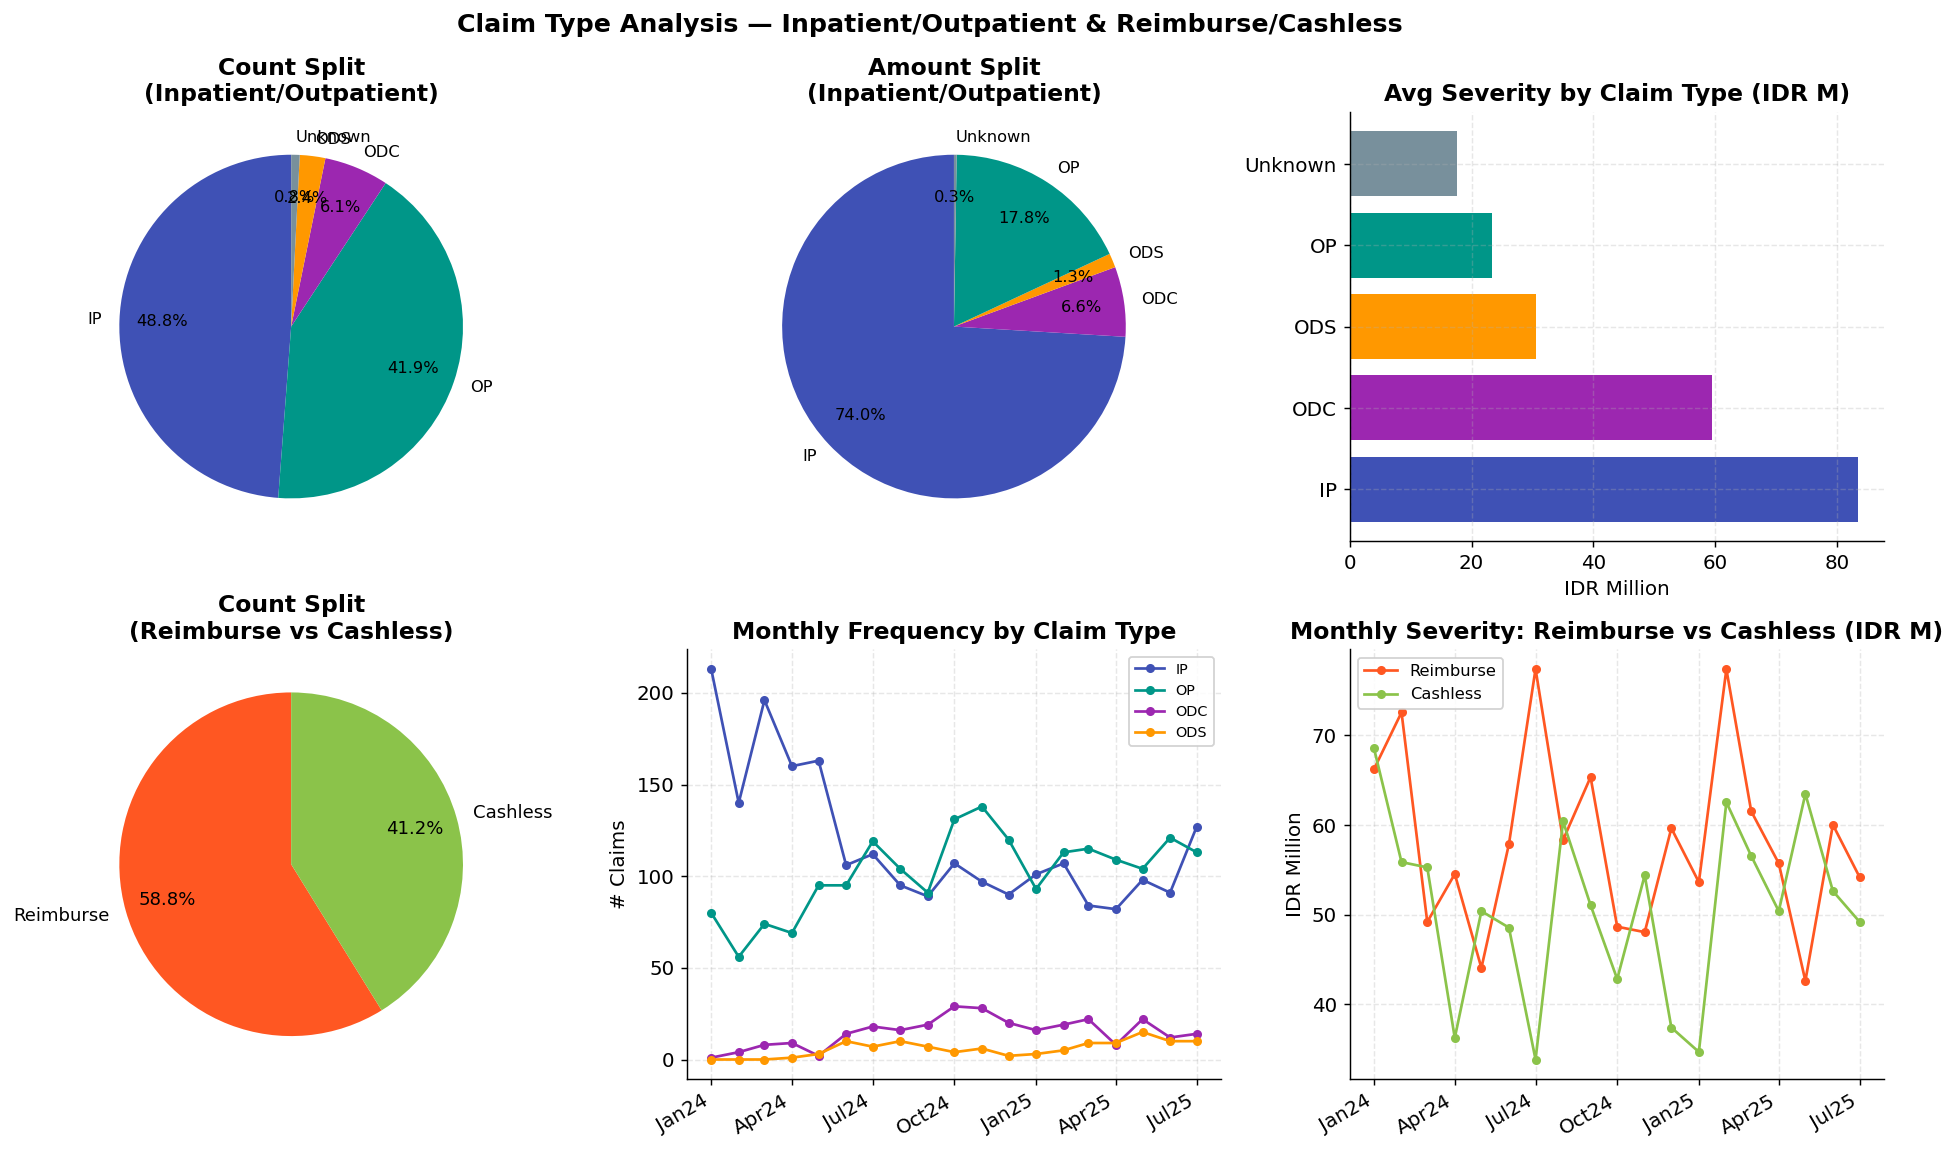


── Claim Type Severity Comparison ──


,n,Mean IDR,Median IDR,Std IDR
claim_type,,,,
IP,"2,258","83,498,979","26,717,745","176,020,589"
ODC,281,"59,545,793","37,213,118","67,614,308"
ODS,111,"30,571,148","16,567,000","39,421,419"
OP,"1,940","23,351,731","2,688,700","51,961,595"
Unknown,37,"17,567,961","2,500,000","28,483,306"


In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Claim Type Analysis — Inpatient/Outpatient & Reimburse/Cashless', fontsize=14, fontweight='bold')

TYPE_COLORS = {'IP': C['ip'], 'OP': C['op'], 'ODC': '#9C27B0', 'ODS': '#FF9800', 'Unknown': C['neutral']}
CHAN_COLORS  = {'Reimburse': C['r'], 'Cashless': C['c']}

# ── Pie: count split ──────────────────────────────────────────────────────────
ct_cnt = df['claim_type'].value_counts()
axes[0, 0].pie(ct_cnt.values, labels=ct_cnt.index, autopct='%1.1f%%',
               colors=[TYPE_COLORS.get(t, C['neutral']) for t in ct_cnt.index],
               startangle=90, pctdistance=0.75, textprops={'fontsize': 9})
axes[0, 0].set_title('Count Split\n(Inpatient/Outpatient)')

# ── Pie: amount split ─────────────────────────────────────────────────────────
ct_amt = df.groupby('claim_type')['approved_claim'].sum()
axes[0, 1].pie(ct_amt.values, labels=ct_amt.index, autopct='%1.1f%%',
               colors=[TYPE_COLORS.get(t, C['neutral']) for t in ct_amt.index],
               startangle=90, pctdistance=0.75, textprops={'fontsize': 9})
axes[0, 1].set_title('Amount Split\n(Inpatient/Outpatient)')

# ── Bar: avg severity by type ─────────────────────────────────────────────────
ct_sev = df.groupby('claim_type')['approved_claim'].mean().sort_values(ascending=False)
axes[0, 2].barh(ct_sev.index, ct_sev.values / 1e6,
                color=[TYPE_COLORS.get(t, C['neutral']) for t in ct_sev.index])
axes[0, 2].set_title('Avg Severity by Claim Type (IDR M)')
axes[0, 2].set_xlabel('IDR Million')

# ── Channel split ─────────────────────────────────────────────────────────────
ch_cnt = df['channel'].value_counts()
axes[1, 0].pie(ch_cnt.values, labels=ch_cnt.index, autopct='%1.1f%%',
               colors=[CHAN_COLORS.get(c, C['neutral']) for c in ch_cnt.index],
               startangle=90, pctdistance=0.75, textprops={'fontsize': 10})
axes[1, 0].set_title('Count Split\n(Reimburse vs Cashless)')

# ── Monthly type trend ────────────────────────────────────────────────────────
type_monthly = df.groupby(['ym', 'claim_type'])['Claim ID'].count().unstack(fill_value=0).reset_index()
type_monthly['date'] = type_monthly['ym'].apply(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))
type_monthly = type_monthly.sort_values('date')
for col in ['IP','OP','ODC','ODS']:
    if col in type_monthly.columns:
        axes[1, 1].plot(type_monthly['date'], type_monthly[col],
                        marker='o', ms=4, label=col, color=TYPE_COLORS.get(col, C['neutral']))
axes[1, 1].set_title('Monthly Frequency by Claim Type')
axes[1, 1].set_ylabel('# Claims')
axes[1, 1].legend(fontsize=8)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1, 1].get_xticklabels(), rotation=30, ha='right')

# ── IP severity monthly ───────────────────────────────────────────────────────
for ch, col in [('Reimburse', C['r']), ('Cashless', C['c'])]:
    sub = df[df['channel']==ch].groupby('ym').agg(
        freq=('Claim ID','count'), tot=('approved_claim','sum')).reset_index()
    sub['sev']  = sub['tot'] / sub['freq']
    sub['date'] = sub['ym'].apply(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))
    axes[1, 2].plot(sub['date'], sub['sev'] / 1e6, marker='o', ms=4, label=ch, color=col)
axes[1, 2].set_title('Monthly Severity: Reimburse vs Cashless (IDR M)')
axes[1, 2].set_ylabel('IDR Million')
axes[1, 2].legend(fontsize=9)
axes[1, 2].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
axes[1, 2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1, 2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
savefig('eda_07_claim_type')
plt.show()

print('\n── Claim Type Severity Comparison ──')
display(df.groupby('claim_type')['approved_claim']
          .agg(['count','mean','median','std'])
          .rename(columns={'count':'n','mean':'Mean IDR','median':'Median IDR','std':'Std IDR'})
          .applymap(lambda x: f'{x:,.0f}'))

---
## 6. Geographic Analysis
> **Prediction insight:** Singapore claims have 3.7× higher average severity than Indonesia — location mix affects aggregate severity.

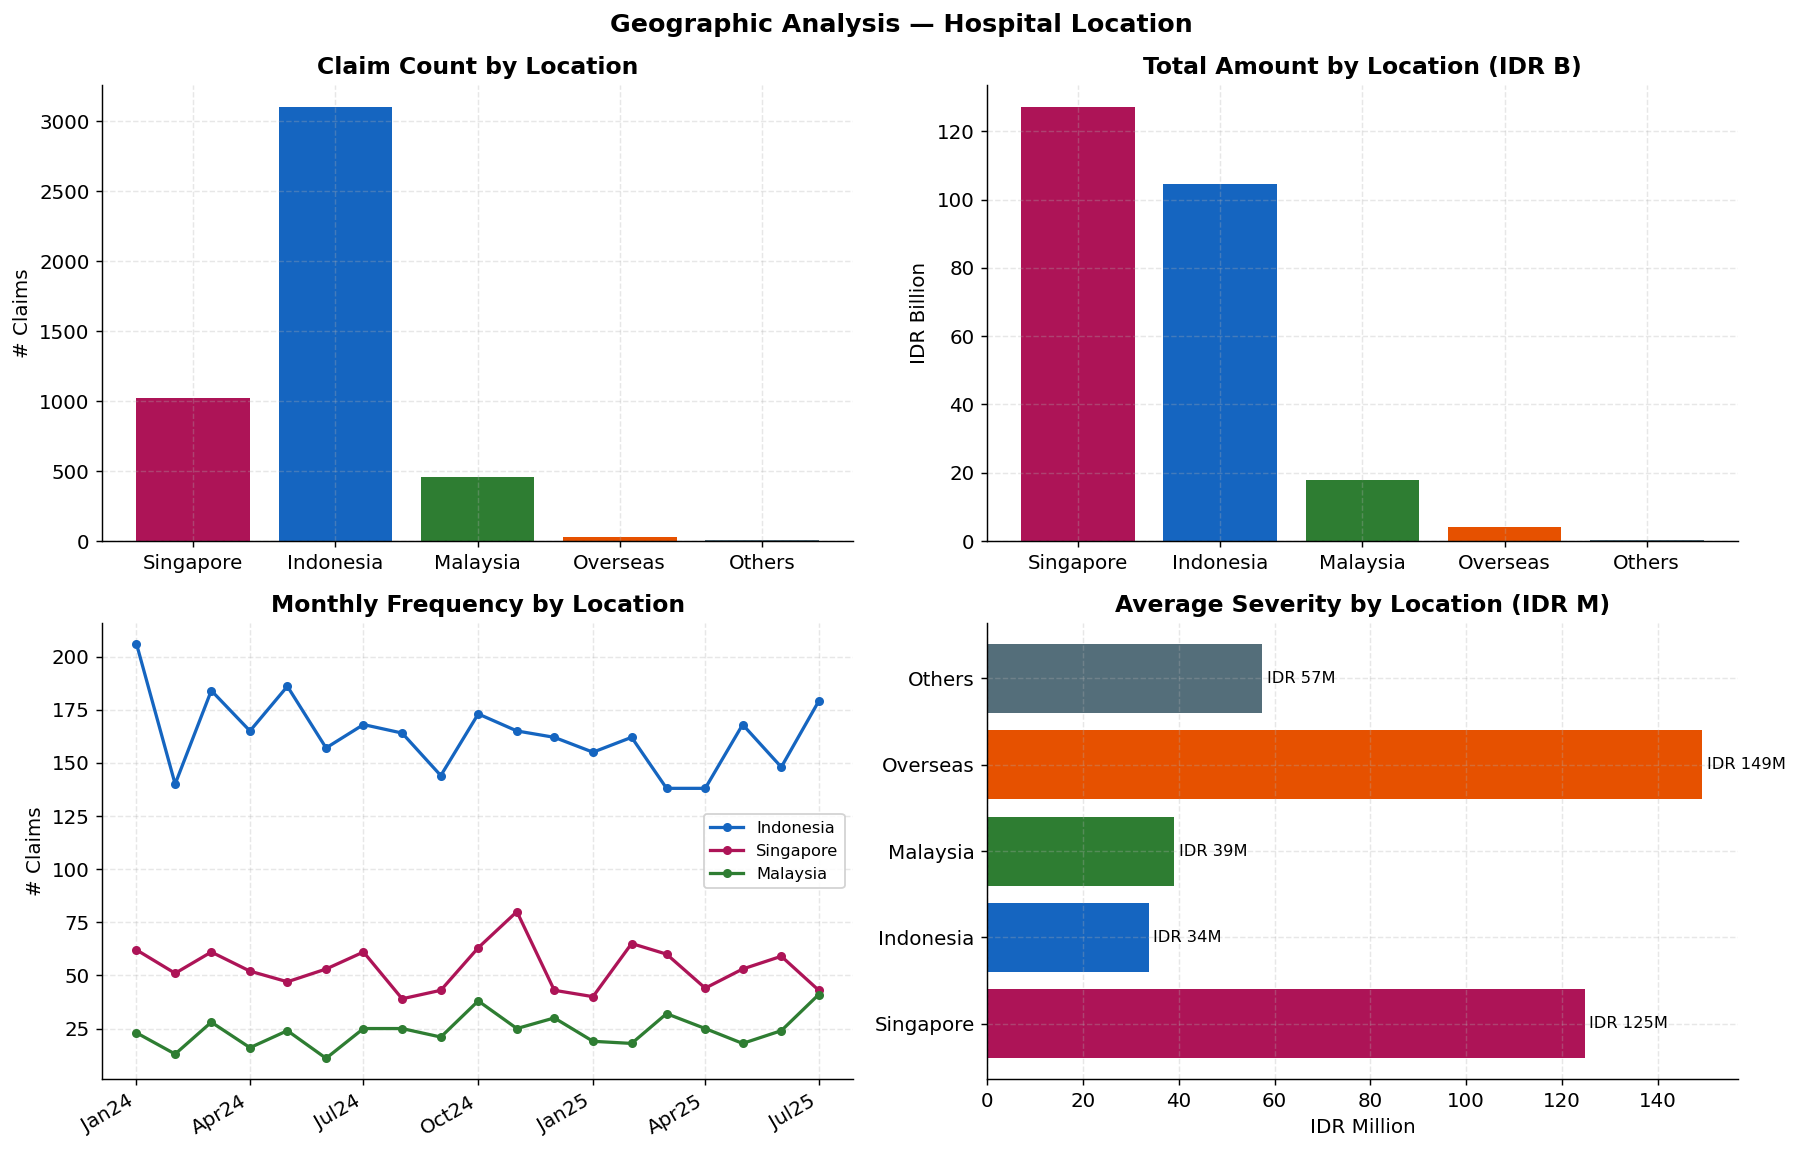

,n,pct_count,pct_amount,avg_sev_M
location,,,,
Singapore,1019,22.1%,50.0%,IDR 124.7M
Indonesia,3102,67.3%,41.2%,IDR 33.7M
Malaysia,456,9.9%,7.0%,IDR 39.1M
Overseas,28,0.6%,1.6%,IDR 149.2M
Others,6,0.1%,0.1%,IDR 57.4M


In [52]:
LOC_COLORS = {'Indonesia':'#1565C0','Singapore':'#AD1457','Malaysia':'#2E7D32',
              'Overseas':'#E65100','Others':'#546E7A'}
MAIN_LOCS  = ['Indonesia','Singapore','Malaysia','Overseas','Others']

loc_stats = (df[df['location'].isin(MAIN_LOCS)]
             .groupby('location')['approved_claim']
             .agg(['count','sum','mean'])
             .rename(columns={'count':'n','sum':'total','mean':'avg_sev'})
             .sort_values('total', ascending=False))

loc_monthly = (
    df[df['location'].isin(MAIN_LOCS)]
    .groupby(['ym','location']).agg(freq=('Claim ID','count'), tot=('approved_claim','sum'))
    .reset_index()
)
loc_monthly['sev']  = loc_monthly['tot'] / loc_monthly['freq']
loc_monthly['date'] = loc_monthly['ym'].apply(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Geographic Analysis — Hospital Location', fontsize=14, fontweight='bold')

# ── Count & Amount bars ───────────────────────────────────────────────────────
axes[0, 0].bar(loc_stats.index, loc_stats['n'], color=[LOC_COLORS.get(l, C['neutral']) for l in loc_stats.index])
axes[0, 0].set_title('Claim Count by Location')
axes[0, 0].set_ylabel('# Claims')

axes[0, 1].bar(loc_stats.index, loc_stats['total'] / 1e9, color=[LOC_COLORS.get(l, C['neutral']) for l in loc_stats.index])
axes[0, 1].set_title('Total Amount by Location (IDR B)')
axes[0, 1].set_ylabel('IDR Billion')

# ── Monthly frequency trend ───────────────────────────────────────────────────
for loc in ['Indonesia','Singapore','Malaysia']:
    sub = loc_monthly[loc_monthly['location']==loc]
    axes[1, 0].plot(sub['date'], sub['freq'], marker='o', ms=4, lw=1.8,
                    label=loc, color=LOC_COLORS.get(loc, C['neutral']))
axes[1, 0].set_title('Monthly Frequency by Location')
axes[1, 0].set_ylabel('# Claims')
axes[1, 0].legend(fontsize=9)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
axes[1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1, 0].get_xticklabels(), rotation=30, ha='right')

# ── Avg severity comparison ───────────────────────────────────────────────────
axes[1, 1].barh(loc_stats.index, loc_stats['avg_sev'] / 1e6,
                color=[LOC_COLORS.get(l, C['neutral']) for l in loc_stats.index])
axes[1, 1].set_title('Average Severity by Location (IDR M)')
axes[1, 1].set_xlabel('IDR Million')
for i, (loc, row) in enumerate(loc_stats.iterrows()):
    axes[1, 1].text(row['avg_sev']/1e6 + 1, i, f"IDR {row['avg_sev']/1e6:.0f}M", va='center', fontsize=9)

plt.tight_layout()
savefig('eda_08_geographic')
plt.show()

display(loc_stats.assign(
    pct_count = lambda d: (d['n']/d['n'].sum()*100).map('{:.1f}%'.format),
    pct_amount= lambda d: (d['total']/d['total'].sum()*100).map('{:.1f}%'.format),
    avg_sev_M = lambda d: (d['avg_sev']/1e6).map('IDR {:.1f}M'.format)
)[['n','pct_count','pct_amount','avg_sev_M']])

---
## 7. Diagnosis (ICD) Analysis
> **Prediction insight:** Top diagnoses drive bulk of amount — shifts in chronic disease volume dominate severity.

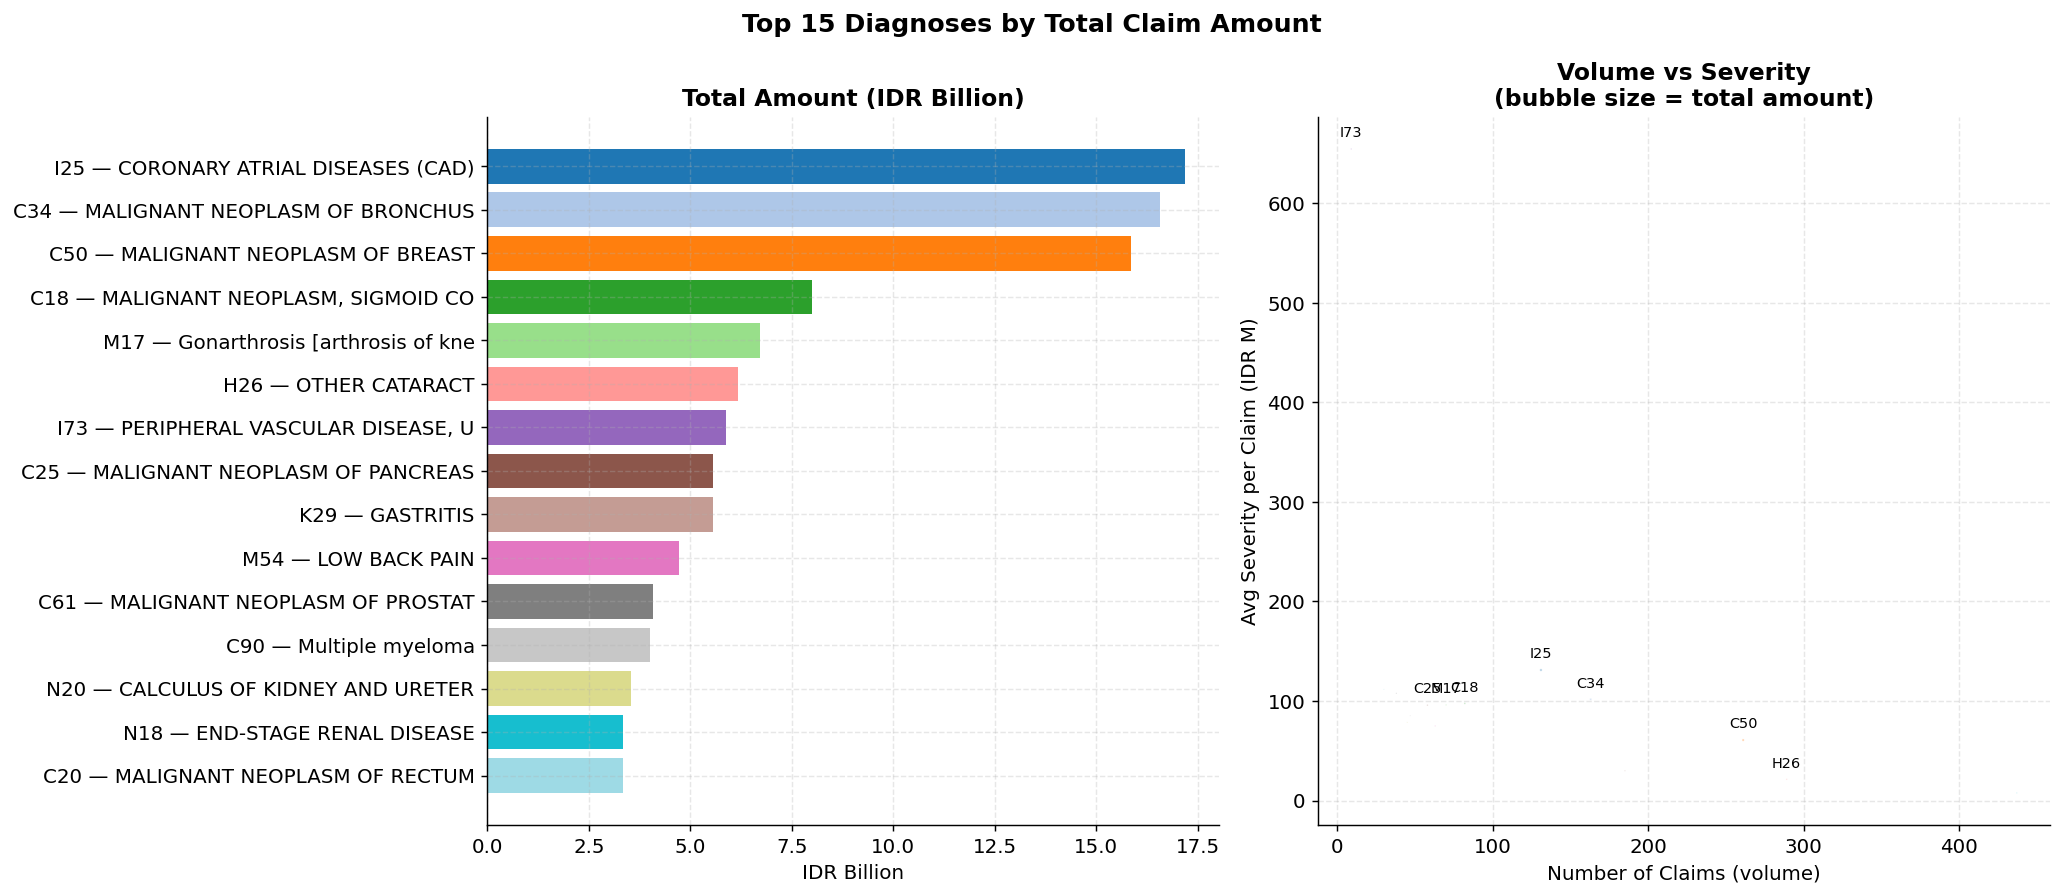

Top 5 diagnoses account for 25.3% of total paid amount


In [53]:
# ── Top 15 diagnoses by total amount ─────────────────────────────────────────
# Map ICD3 → description (use most frequent description per ICD3)
icd_desc = df.groupby('icd3')['ICD Description'].agg(lambda x: x.mode()[0] if len(x) > 0 else 'N/A')
icd_stats = (
    df.groupby('icd3')['approved_claim']
    .agg(['count','sum','mean'])
    .rename(columns={'count':'n','sum':'total','mean':'avg_sev'})
    .join(icd_desc)
    .sort_values('total', ascending=False)
    .head(15)
)
icd_stats['label'] = icd_stats.index + ' — ' + icd_stats['ICD Description'].str[:30]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 15 Diagnoses by Total Claim Amount', fontsize=14, fontweight='bold')

# Total amount
pal = plt.cm.get_cmap('tab20', len(icd_stats))
colors = [pal(i) for i in range(len(icd_stats))]
axes[0].barh(icd_stats['label'][::-1], icd_stats['total'][::-1] / 1e9, color=colors[::-1])
axes[0].set_title('Total Amount (IDR Billion)')
axes[0].set_xlabel('IDR Billion')

# Avg severity vs count (bubble chart)
sc = axes[1].scatter(icd_stats['n'], icd_stats['avg_sev'] / 1e6,
                     s=icd_stats['total'] / 1e10, alpha=0.7, c=colors, edgecolors='white', lw=0.8)
for _, row in icd_stats.head(8).iterrows():
    axes[1].annotate(row.name, xy=(row['n'], row['avg_sev']/1e6),
                     fontsize=8, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')
axes[1].set_title('Volume vs Severity\n(bubble size = total amount)')
axes[1].set_xlabel('Number of Claims (volume)')
axes[1].set_ylabel('Avg Severity per Claim (IDR M)')

plt.tight_layout()
savefig('eda_09_icd_analysis')
plt.show()

top5_pct = icd_stats['total'].head(5).sum() / df['approved_claim'].sum() * 100
print(f'Top 5 diagnoses account for {top5_pct:.1f}% of total paid amount')

---
## 8. Severity Drivers & Outlier Detection
> **Prediction insight:** Feb 2025 and Jan 2024 are statistically extreme months — winsorization or exclusion is needed.

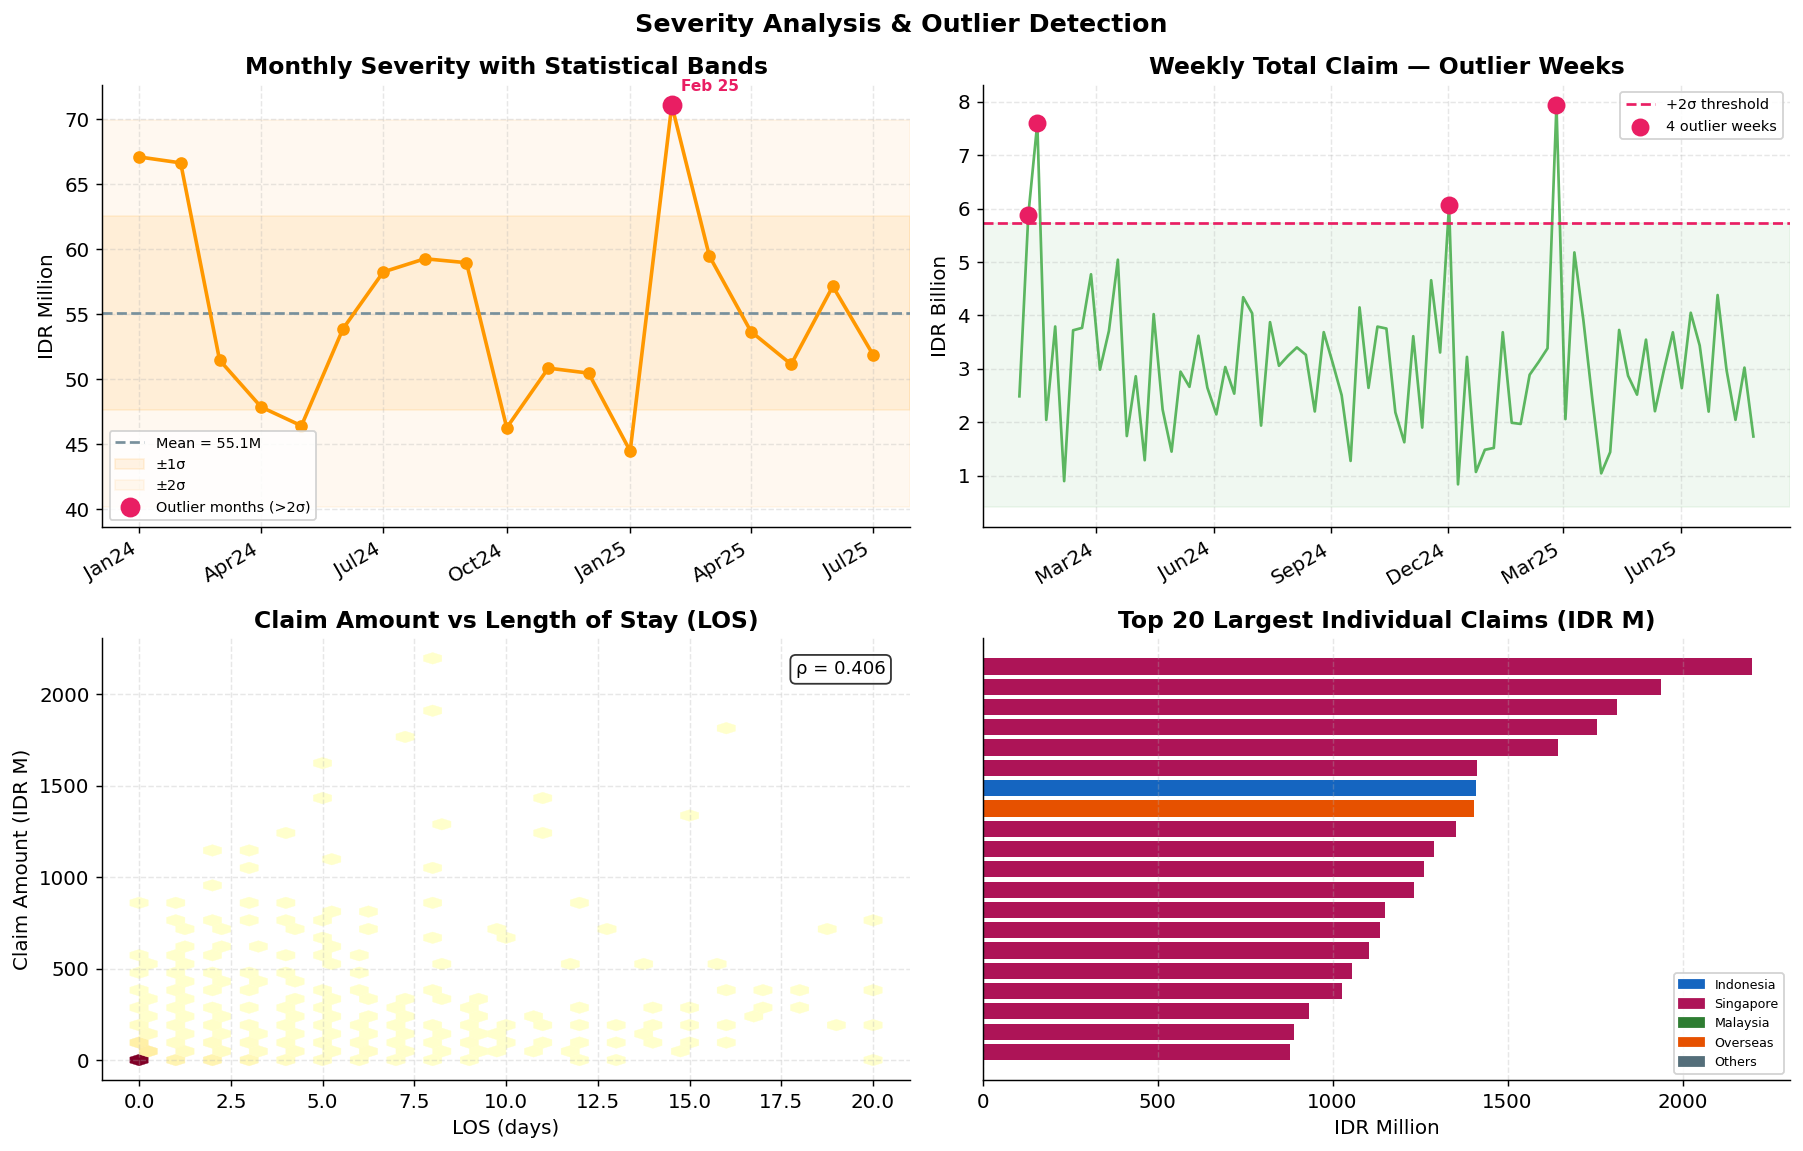

Monthly outliers (>2σ from mean severity): ['Feb 2025']
Weekly outliers (>2σ from mean total):     4 weeks


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Severity Analysis & Outlier Detection', fontsize=14, fontweight='bold')

# ── Monthly severity with ±1σ / ±2σ bands ────────────────────────────────────
ax = axes[0, 0]
mu, sig = monthly['severity'].mean(), monthly['severity'].std()
ax.plot(monthly['date'], monthly['severity'] / 1e6, marker='o', color=C['sev'], lw=2, zorder=3)
ax.axhline(mu / 1e6, color=C['neutral'], lw=1.5, linestyle='--', label=f'Mean = {mu/1e6:.1f}M')
ax.axhspan((mu - sig)  / 1e6, (mu + sig)  / 1e6, alpha=0.10, color=C['sev'], label='±1σ')
ax.axhspan((mu - 2*sig)/ 1e6, (mu + 2*sig)/ 1e6, alpha=0.06, color=C['sev'], label='±2σ')
# Flag outliers
outliers = monthly[np.abs(monthly['severity'] - mu) > 2 * sig]
ax.scatter(outliers['date'], outliers['severity'] / 1e6, color=C['accent'], zorder=5, s=100,
           label=f'Outlier months (>{2}σ)')
for _, row in outliers.iterrows():
    ax.annotate(f"{row['date'].strftime('%b %y')}",
                xy=(row['date'], row['severity']/1e6),
                xytext=(5, 8), textcoords='offset points', fontsize=8.5, color=C['accent'], fontweight='bold')
ax.set_title('Monthly Severity with Statistical Bands')
ax.set_ylabel('IDR Million')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Weekly total with outlier bands ──────────────────────────────────────────
ax = axes[0, 1]
wmu, wsig = weekly['total_claim'].mean(), weekly['total_claim'].std()
ax.plot(weekly['ws'], weekly['total_claim'] / 1e9, color=C['total'], lw=1.5, alpha=0.9)
ax.axhspan((wmu - 2*wsig)/1e9, (wmu + 2*wsig)/1e9, alpha=0.08, color=C['total'])
ax.axhline((wmu + 2*wsig)/1e9, color=C['accent'], lw=1.5, linestyle='--', label='+2σ threshold')
outlier_weeks = weekly[weekly['total_claim'] > wmu + 2*wsig]
ax.scatter(outlier_weeks['ws'], outlier_weeks['total_claim']/1e9,
           color=C['accent'], s=80, zorder=5, label=f'{len(outlier_weeks)} outlier weeks')
ax.set_title('Weekly Total Claim — Outlier Weeks')
ax.set_ylabel('IDR Billion')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── LOS vs Amount scatter ─────────────────────────────────────────────────────
ax = axes[1, 0]
los_clip = df[df['los'].between(0, 20)]
ax.hexbin(los_clip['los'], los_clip['approved_claim'] / 1e6, gridsize=40,
          cmap='YlOrRd', mincnt=1, linewidths=0.2)
ax.set_title('Claim Amount vs Length of Stay (LOS)')
ax.set_xlabel('LOS (days)')
ax.set_ylabel('Claim Amount (IDR M)')
corr = df[['los','approved_claim']].corr().iloc[0,1]
ax.text(0.97, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# ── Top 20 single claims ──────────────────────────────────────────────────────
ax = axes[1, 1]
top20 = df.nlargest(20, 'approved_claim')[['approved_claim','location','claim_type']].copy()
top20['approved_claim'] /= 1e6
bar_colors_top = [LOC_COLORS.get(l, C['neutral']) for l in top20['location']]
ax.barh(range(20), top20['approved_claim'].values[::-1], color=bar_colors_top[::-1])
ax.set_title('Top 20 Largest Individual Claims (IDR M)')
ax.set_xlabel('IDR Million')
ax.set_yticks([])
handles = [mpatches.Patch(color=v, label=k) for k, v in LOC_COLORS.items()]
ax.legend(handles=handles, fontsize=7, loc='lower right')

plt.tight_layout()
savefig('eda_10_severity_outliers')
plt.show()

print(f'Monthly outliers (>2σ from mean severity): {list(outliers["date"].dt.strftime("%b %Y"))}')
print(f'Weekly outliers (>2σ from mean total):     {len(outlier_weeks)} weeks')

---
## 9. Year-over-Year Comparison
> **Prediction insight:** YoY ratios are the anchor for the seasonal-naive component — 2025 tracks ~94% of 2024 frequency.

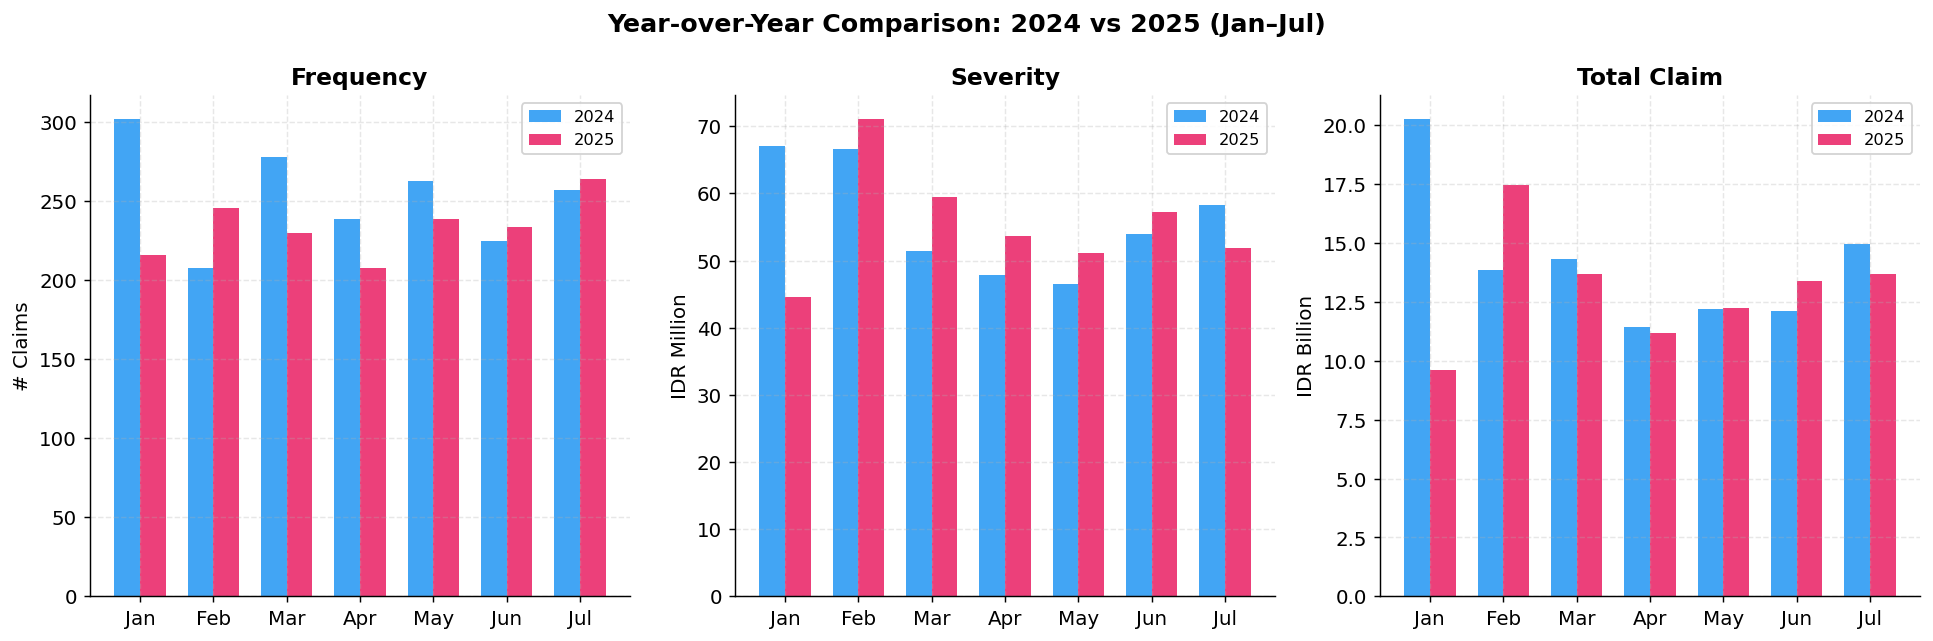

In [55]:
# ── Side-by-side 2024 vs 2025 (Jan–Jul only) ──────────────────────────────────
m2024 = monthly[monthly['date'].dt.year == 2024].copy().reset_index(drop=True)
m2025 = monthly[monthly['date'].dt.year == 2025].copy().reset_index(drop=True)
common_months = [m for m in range(1, 8)]   # Jan–Jul (available in both years)

m2024_c = m2024[m2024['date'].dt.month.isin(common_months)].reset_index(drop=True)
m2025_c = m2025[m2025['date'].dt.month.isin(common_months)].reset_index(drop=True)
x  = np.arange(len(common_months))
mn = [month_names[m-1] for m in common_months]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Year-over-Year Comparison: 2024 vs 2025 (Jan–Jul)', fontsize=14, fontweight='bold')

for ax, col, scale, label, t in zip(
    axes,
    ['frequency', 'severity', 'total_claim'],
    [1, 1e6, 1e9],
    ['# Claims', 'IDR Million', 'IDR Billion'],
    ['Frequency', 'Severity', 'Total Claim']
):
    w = 0.35
    b1 = ax.bar(x - w/2, m2024_c[col] / scale, w, label='2024', color=C['freq'],    alpha=0.85)
    b2 = ax.bar(x + w/2, m2025_c[col] / scale, w, label='2025', color=C['accent'],  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(mn, rotation=0)
    ax.set_title(t)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)

plt.tight_layout()
savefig('eda_11_yoy_comparison')
plt.show()

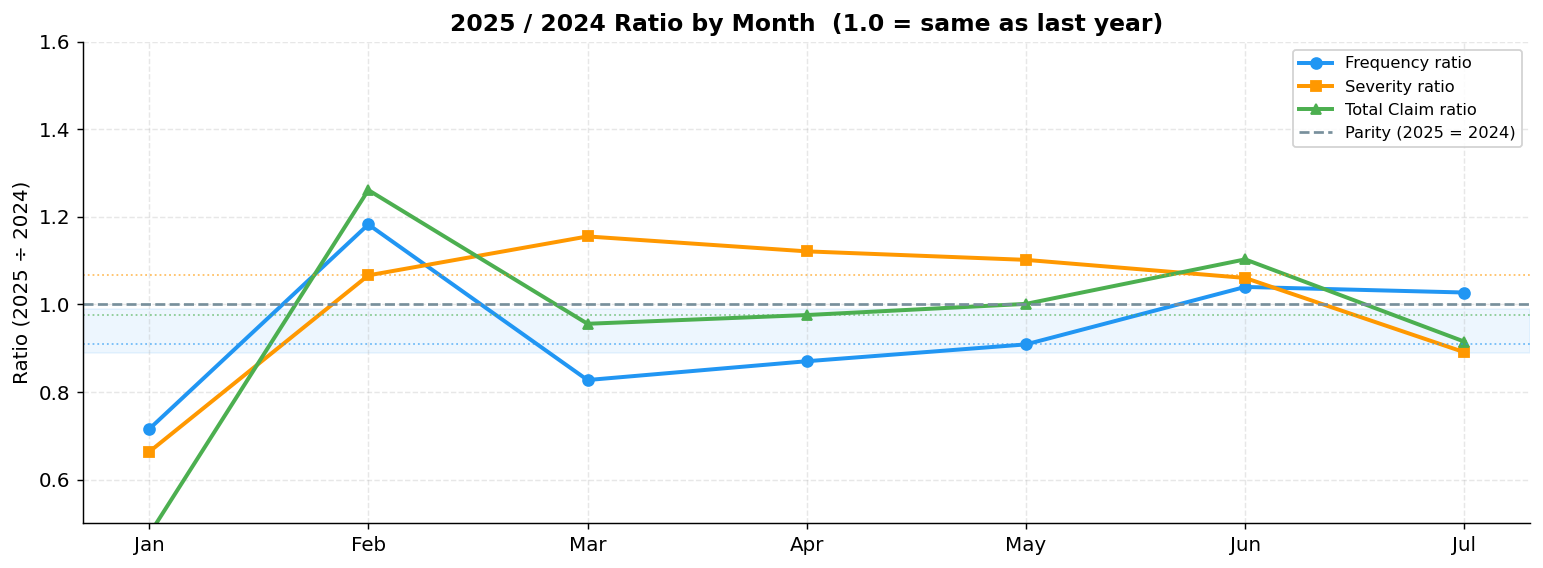


── YoY Ratio Table ──


,Freq ratio,Sev ratio,Tot ratio
month_name,,,
Jan,0.715,0.663,0.474
Feb,1.183,1.066,1.261
Mar,0.827,1.155,0.956
Apr,0.870,1.121,0.976
May,0.909,1.102,1.001
Jun,1.040,1.061,1.103
Jul,1.027,0.891,0.915



Median YoY ratios → Freq: 0.909  Sev: 1.066  Total: 0.976
→ Used as the YoY scaler in the Seasonal Naïve model component


In [56]:
# ── YoY ratio table + line chart ──────────────────────────────────────────────
yoy = pd.DataFrame({
    'month': common_months,
    'month_name': mn,
    'freq_2024':  m2024_c['frequency'].values,
    'freq_2025':  m2025_c['frequency'].values,
    'sev_2024':   m2024_c['severity'].values,
    'sev_2025':   m2025_c['severity'].values,
    'tot_2024':   m2024_c['total_claim'].values,
    'tot_2025':   m2025_c['total_claim'].values,
})
yoy['freq_ratio'] = yoy['freq_2025'] / yoy['freq_2024']
yoy['sev_ratio']  = yoy['sev_2025']  / yoy['sev_2024']
yoy['tot_ratio']  = yoy['tot_2025']  / yoy['tot_2024']

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(yoy['month_name'], yoy['freq_ratio'], marker='o', lw=2.2, color=C['freq'],  label='Frequency ratio')
ax.plot(yoy['month_name'], yoy['sev_ratio'],  marker='s', lw=2.2, color=C['sev'],   label='Severity ratio')
ax.plot(yoy['month_name'], yoy['tot_ratio'],  marker='^', lw=2.2, color=C['total'], label='Total Claim ratio')
ax.axhline(1.0, color=C['neutral'], lw=1.5, linestyle='--', label='Parity (2025 = 2024)')
ax.axhspan(yoy['freq_ratio'].mean() - 0.05, yoy['freq_ratio'].mean() + 0.05,
           alpha=0.08, color=C['freq'])
ax.set_title('2025 / 2024 Ratio by Month  (1.0 = same as last year)', fontsize=13)
ax.set_ylabel('Ratio (2025 ÷ 2024)')
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.6)

# Annotate medians
for col, label, yoff in [('freq_ratio', f"Freq median={yoy['freq_ratio'].median():.2f}", -0.12),
                           ('sev_ratio',  f"Sev  median={yoy['sev_ratio'].median():.2f}",   0.08),
                           ('tot_ratio',  f"Tot  median={yoy['tot_ratio'].median():.2f}",  -0.22)]:
    ax.axhline(yoy[col].median(), color=ax.lines[['freq_ratio','sev_ratio','tot_ratio'].index(col)].get_color(),
               lw=1, linestyle=':', alpha=0.6)

plt.tight_layout()
savefig('eda_12_yoy_ratio')
plt.show()

print('\n── YoY Ratio Table ──')
display(yoy[['month_name','freq_ratio','sev_ratio','tot_ratio']]
        .set_index('month_name')
        .rename(columns={'freq_ratio':'Freq ratio','sev_ratio':'Sev ratio','tot_ratio':'Tot ratio'})
        .style.format('{:.3f}').background_gradient(cmap='RdYlGn', vmin=0.7, vmax=1.3))

print(f"\nMedian YoY ratios → Freq: {yoy['freq_ratio'].median():.3f}  "
      f"Sev: {yoy['sev_ratio'].median():.3f}  "
      f"Total: {yoy['tot_ratio'].median():.3f}")
print("→ Used as the YoY scaler in the Seasonal Naïve model component")

In [57]:
# ── Final summary statistics table ────────────────────────────────────────────
print('═'*65)
print('  FINAL SUMMARY — Key Numbers for the Report')
print('═'*65)
print(f"  Total claims               : {len(df):,}")
print(f"  Observation period         : {df['admission_date'].min().date()} → {df['admission_date'].max().date()}")
print(f"  Total paid amount          : IDR {df['approved_claim'].sum()/1e12:.3f} Trillion")
print(f"  Avg monthly frequency      : {monthly['frequency'].mean():.0f} claims")
print(f"  Avg monthly severity       : IDR {monthly['severity'].mean()/1e6:.1f} Million")
print(f"  Avg monthly total claim    : IDR {monthly['total_claim'].mean()/1e9:.2f} Billion")
print(f"  Severity outlier months    : {', '.join(outliers['date'].dt.strftime('%b %Y'))}")
print(f"  Frequency CoV (monthly)    : {monthly['frequency'].std()/monthly['frequency'].mean():.3f}")
print(f"  Severity CoV (monthly)     : {monthly['severity'].std()/monthly['severity'].mean():.3f}")
print(f"  Top ICD by amount          : I25 (Ischaemic heart disease) — IDR 17.2B")
print(f"  Top location by amount     : Singapore (IDR 127B, {1019/len(df)*100:.1f}% of claims)")
print(f"  IP claim avg severity      : IDR {df[df['claim_type']=='IP']['approved_claim'].mean()/1e6:.0f}M")
print(f"  OP claim avg severity      : IDR {df[df['claim_type']=='OP']['approved_claim'].mean()/1e6:.0f}M")
print(f"  Median YoY frequency ratio : {yoy['freq_ratio'].median():.3f}")
print(f"  Median YoY severity ratio  : {yoy['sev_ratio'].median():.3f}")
print('═'*65)
print(f"  All figures saved to: {OUTPUT_DIR.resolve()}")

═════════════════════════════════════════════════════════════════
  FINAL SUMMARY — Key Numbers for the Report
═════════════════════════════════════════════════════════════════
  Total claims               : 4,627
  Observation period         : 2024-01-01 → 2025-07-31
  Total paid amount          : IDR 0.255 Trillion
  Avg monthly frequency      : 244 claims
  Avg monthly severity       : IDR 55.1 Million
  Avg monthly total claim    : IDR 13.40 Billion
  Severity outlier months    : Feb 2025
  Frequency CoV (monthly)    : 0.109
  Severity CoV (monthly)     : 0.135
  Top ICD by amount          : I25 (Ischaemic heart disease) — IDR 17.2B
  Top location by amount     : Singapore (IDR 127B, 22.0% of claims)
  IP claim avg severity      : IDR 83M
  OP claim avg severity      : IDR 23M
  Median YoY frequency ratio : 0.909
  Median YoY severity ratio  : 1.066
═════════════════════════════════════════════════════════════════
  All figures saved to: C:\Users\Robben's Laptop\OneDrive\Documents\

# Forecasting Model
### Predict Monthly Claim Frequency, Severity & Total (Aug–Dec 2025)

---

| Item | Detail |
|------|--------|
| **Target** | Claim Frequency, Claim Severity, Total Claim |
| **Horizon** | August – December 2025 (5 months) |
| **Granularity** | Weekly → Monthly rollup |
| **Evaluation** | MAPE (Mean Absolute Percentage Error) |

**Notebook Sections**
1. Setup & Data Loading  
2. Data Preparation  
3. Feature Engineering & Transformation  
4. Time-Based Cross Validation  
5. Baseline Time-Series Models  
6. Classic Statistical Models (SES, ARIMA, SARIMA, Theta)  
7. Gradient Boosting Model (LightGBM)  
8. Linear Decomposition Models (NLinear, DLinear)  
9. Ensemble Learning & Model Blending  
10. Final Predictions & Submission

---
## 1. Setup & Data Loading

In [58]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Data & Math ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from numpy.linalg import lstsq
from scipy.optimize import minimize_scalar, minimize
from scipy.stats import mstats

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("[INFO] LightGBM not found — Gradient Boosting section will be skipped.")

# ── Statistical ───────────────────────────────────────────────────────────────
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from pmdarima import auto_arima
    HAS_STATSMODELS = True
    HAS_PMDARIMA = True
except ImportError:
    HAS_STATSMODELS = False
    HAS_PMDARIMA = False
    print("[INFO] statsmodels/pmdarima not found — ARIMA/SARIMA will use fallback.")

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('data')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Setup complete.')
print(f'  Data dir   : {DATA_DIR.resolve()}')
print(f'  Output dir : {OUTPUT_DIR.resolve()}')

Setup complete.
  Data dir   : C:\Users\Robben's Laptop\OneDrive\Documents\Personal Projects\mcfitb-dsc-2026\data
  Output dir : C:\Users\Robben's Laptop\OneDrive\Documents\Personal Projects\mcfitb-dsc-2026\output


In [59]:
# ── Raw Load ──────────────────────────────────────────────────────────────────
df_klaim = pd.read_csv(DATA_DIR / 'Data_Klaim.csv')
df_polis = pd.read_csv(DATA_DIR / 'Data_Polis.csv')

print(f'Data_Klaim : {df_klaim.shape[0]:,} rows × {df_klaim.shape[1]} cols')
print(f'Data_Polis : {df_polis.shape[0]:,} rows × {df_polis.shape[1]} cols')
print()
df_klaim.head(3)

Data_Klaim : 4,627 rows × 13 cols
Data_Polis : 4,096 rows × 6 cols



,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore


---
## 2. Data Preparation

### 2.1 Parsing & Typing

In [60]:
# ── Parse dates & amounts ─────────────────────────────────────────────────────
df_klaim['date']   = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'])
df_klaim['amount'] = pd.to_numeric(df_klaim['Nominal Klaim Yang Disetujui'], errors='coerce')
df_klaim['ym']     = list(zip(df_klaim['date'].dt.year, df_klaim['date'].dt.month))
df_klaim['week']   = df_klaim['date'].dt.to_period('W')

print('Date range :', df_klaim['date'].min().date(), '→', df_klaim['date'].max().date())
print('Null amounts:', df_klaim['amount'].isna().sum())
df_klaim[['date','amount']].describe()

Date range : 2024-01-01 → 2025-07-31
Null amounts: 0


,date,amount
count,4627,4.627000e+03
mean,2024-10-10 18:15:28.982061824,5.502892e+07
min,2024-01-01 00:00:00,0.000000e+00
25%,2024-05-16 12:00:00,2.274009e+06
50%,2024-10-11 00:00:00,1.446790e+07
75%,2025-03-03 00:00:00,5.107209e+07
max,2025-07-31 00:00:00,2.197500e+09
std,NaN,1.319527e+08


### 2.2 Monthly Aggregation (Ground Truth)

In [61]:
# ── Monthly ground truth ──────────────────────────────────────────────────────
monthly = (
    df_klaim
    .groupby('ym')
    .agg(frequency=('Claim ID', 'count'),
         total_claim=('amount', 'sum'))
    .reset_index()
)
monthly['severity'] = monthly['total_claim'] / monthly['frequency']
monthly = monthly.sort_values('ym').reset_index(drop=True)
monthly['date'] = monthly['ym'].apply(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))

print(f'Monthly rows : {len(monthly)}')
print(f'Period       : {monthly["ym"].iloc[0]} → {monthly["ym"].iloc[-1]}')
monthly[['date','frequency','severity','total_claim']].tail(8)

Monthly rows : 19
Period       : (2024, 1) → (2025, 7)


,date,frequency,severity,total_claim
11,2024-12-01,238,5.047861e+07,1.201391e+10
12,2025-01-01,216,4.449250e+07,9.610380e+09
13,2025-02-01,246,7.105911e+07,1.748054e+10
14,2025-03-01,230,5.947496e+07,1.367924e+10
15,2025-04-01,208,5.367427e+07,1.116425e+10
16,2025-05-01,239,5.115814e+07,1.222680e+10
17,2025-06-01,234,5.715008e+07,1.337312e+10
18,2025-07-01,264,5.189101e+07,1.369923e+10


### 2.3 Weekly Aggregation

In [62]:
# ── Weekly aggregation ────────────────────────────────────────────────────────
weekly = (
    df_klaim
    .groupby('week')
    .agg(frequency=('Claim ID', 'count'),
         total_claim=('amount', 'sum'))
    .reset_index()
)
weekly['week_start'] = weekly['week'].dt.start_time.dt.normalize()
weekly['week_end']   = weekly['week'].dt.end_time.dt.normalize()
weekly = weekly.sort_values('week_start').reset_index(drop=True)

print(f'Weekly rows : {len(weekly)}')
print(f'Period      : {weekly["week_start"].iloc[0].date()} → {weekly["week_end"].iloc[-1].date()}')
weekly.tail(5)

Weekly rows : 83
Period      : 2024-01-01 → 2025-08-03


,week,frequency,total_claim,week_start,week_end
78,2025-06-30/2025-07-06,53,4.380759e+09,2025-06-30,2025-07-06
79,2025-07-07/2025-07-13,62,2.975892e+09,2025-07-07,2025-07-13
80,2025-07-14/2025-07-20,58,2.043110e+09,2025-07-14,2025-07-20
81,2025-07-21/2025-07-27,64,3.021565e+09,2025-07-21,2025-07-27
82,2025-07-28/2025-08-03,40,1.731912e+09,2025-07-28,2025-08-03


### 2.4 Rollup Utility  
_Convert weekly predictions → monthly totals using day-fraction weighting._

In [63]:
def weekly_to_monthly_rollup(ws_list, we_list, values, target_yms):
    """
    Sum weekly predictions into monthly totals.
    Each day inside a week contributes  value / 7  to its month.
    Partial weeks at month boundaries are handled automatically.
    """
    monthly_sums = {ym: 0.0 for ym in target_yms}
    for ws, we, val in zip(ws_list, we_list, values):
        for day in pd.date_range(ws, we, freq='D'):
            ym = (day.year, day.month)
            if ym in monthly_sums:
                monthly_sums[ym] += val / 7.0
    return monthly_sums


def get_future_weeks(month_start, month_end):
    """Generate (week_start, week_end) pairs covering a calendar month."""
    fws, fwe = [], []
    cursor = month_start
    while cursor <= month_end:
        fws.append(cursor)
        fwe.append(min(cursor + pd.Timedelta(days=6), month_end))
        cursor += pd.Timedelta(days=7)
    return fws, fwe


print('Rollup utilities defined.')

Rollup utilities defined.


---
## 3. Feature Engineering & Transformation

### 2.4.1 Lag Features

In [64]:
def build_lag_features(series: np.ndarray, lookback: int, target_col: str = 'y'):
    """
    Build a supervised learning DataFrame with lag features.

    Parameters
    ----------
    series   : 1-D array of time-series values
    lookback : number of lag steps to include
    target_col : name for the target column

    Returns
    -------
    X : np.ndarray  shape (n - lookback, lookback)
    y : np.ndarray  shape (n - lookback,)
    """
    series = np.array(series, dtype=float)
    n = len(series)
    X = np.stack([series[i : i + lookback] for i in range(n - lookback)])
    y = series[lookback:]
    return X, y


def build_lag_dataframe(series: np.ndarray, lookback: int, target_col: str = 'y'):
    """Same as build_lag_features but returns a tidy DataFrame."""
    X, y = build_lag_features(series, lookback, target_col)
    cols = [f'lag_{i+1}' for i in range(lookback)]
    df = pd.DataFrame(X, columns=cols)
    df[target_col] = y
    return df


# ── Quick demo ────────────────────────────────────────────────────────────────
demo = build_lag_dataframe(weekly['frequency'].values, lookback=4)
print(f'Lag feature matrix shape: {demo.shape}')
demo.head(4)

Lag feature matrix shape: (79, 5)


,lag_1,lag_2,lag_3,lag_4,y
0,46.0,84.0,95.0,48.0,51.0
1,84.0,95.0,48.0,51.0,33.0
2,95.0,48.0,51.0,33.0,44.0
3,48.0,51.0,33.0,44.0,60.0


### 2.4.2 Logarithmic Transformation (Log-Scaling)

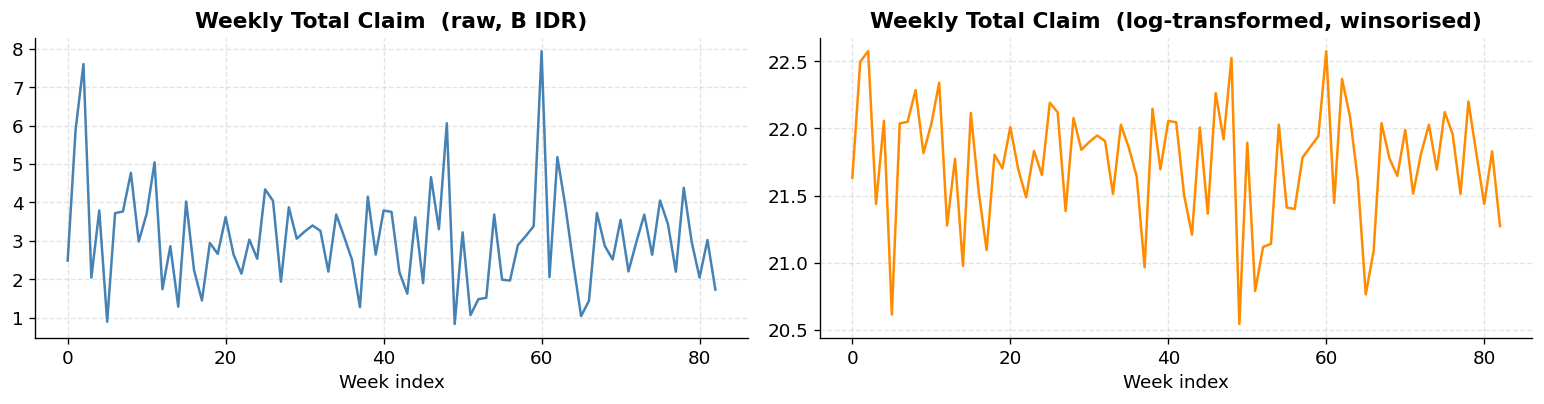

Raw  — skew: 1.118 | CV: 0.430
Log  — skew: -0.606 | CV: 0.020


In [65]:
def winsorize_series(arr: np.ndarray, n_std: float = 2.5) -> np.ndarray:
    """Cap values at mean ± n_std × std (in-place safe)."""
    arr = np.array(arr, dtype=float)
    mu, sigma = arr.mean(), arr.std()
    return np.clip(arr, mu - n_std * sigma, mu + n_std * sigma)


def log_transform(arr: np.ndarray, floor: float = 1.0) -> np.ndarray:
    """Natural log with floor to avoid log(0)."""
    return np.log(np.maximum(np.array(arr, dtype=float), floor))


def exp_transform(arr: np.ndarray) -> np.ndarray:
    """Inverse of log_transform."""
    return np.exp(np.array(arr, dtype=float))


def prepare_series(arr: np.ndarray,
                   use_log: bool = False,
                   winsorize: bool = True,
                   n_std: float = 2.5) -> np.ndarray:
    """Full preprocessing pipeline: winsorize → optional log."""
    arr = np.array(arr, dtype=float)
    if winsorize:
        arr = winsorize_series(arr, n_std)
    if use_log:
        arr = log_transform(arr)
    return arr


# ── Visualise the effect ──────────────────────────────────────────────────────
tot_raw = weekly['total_claim'].values.astype(float)
tot_log = log_transform(winsorize_series(tot_raw))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(tot_raw / 1e9, color='steelblue')
axes[0].set_title('Weekly Total Claim  (raw, B IDR)')
axes[1].plot(tot_log, color='darkorange')
axes[1].set_title('Weekly Total Claim  (log-transformed, winsorised)')
for ax in axes:
    ax.set_xlabel('Week index')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_log_transform.png', bbox_inches='tight')
plt.show()

print(f'Raw  — skew: {pd.Series(tot_raw).skew():.3f} | CV: {tot_raw.std()/tot_raw.mean():.3f}')
print(f'Log  — skew: {pd.Series(tot_log).skew():.3f} | CV: {tot_log.std()/tot_log.mean():.3f}')

---
## 4. Time-Based Cross Validation (Walk-Forward)

### 2.12.1 Walk-Forward Validation

Train on all data **before** each test month → predict that month → evaluate.

In [66]:
# ── Shared CV infrastructure ──────────────────────────────────────────────────
CV_N_TEST_MONTHS = 5   # last 5 months = Mar–Jul 2025

MONTHLY_GT   = {r['ym']: r for _, r in monthly.iterrows()}
ALL_MONTHS   = sorted(monthly['ym'].tolist())
HELD_OUT     = ALL_MONTHS[-CV_N_TEST_MONTHS:]
WEEKLY_WE_PD = pd.DatetimeIndex(weekly['week_end'])

FREQ_RAW = weekly['frequency'].values.astype(float)
TOT_RAW  = weekly['total_claim'].values.astype(float)

print('Walk-forward CV setup')
print(f'  Test months ({CV_N_TEST_MONTHS}): {HELD_OUT}')

Walk-forward CV setup
  Test months (5): [(2025, 3), (2025, 4), (2025, 5), (2025, 6), (2025, 7)]


### 2.12.2 Metrics

In [67]:
def mape(actual: np.ndarray, predicted: np.ndarray) -> float:
    a, p = np.array(actual, float), np.array(predicted, float)
    mask = a != 0
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)


def evaluate_monthly_rollup(pred_freq, pred_total, gt_row) -> dict:
    """Return MAPE dict for frequency, severity, and total."""
    pred_sev = pred_total / pred_freq if pred_freq > 0 else 0.0
    return {
        'freq_ape': abs(gt_row['frequency']   - pred_freq)  / gt_row['frequency']   * 100,
        'sev_ape':  abs(gt_row['severity']    - pred_sev)   / gt_row['severity']    * 100,
        'tot_ape':  abs(gt_row['total_claim'] - pred_total) / gt_row['total_claim'] * 100,
    }


def print_cv_summary(name: str, results: list):
    """Pretty-print walk-forward CV results."""
    hdr = f"{'Month':<14}{'APE_Freq':>10}{'APE_Sev':>10}{'APE_Tot':>10}{'Overall':>10}"
    print(f'\n── {name} CV Results ──')
    print(hdr)
    print('─' * len(hdr))
    all_apes = []
    for r in results:
        ov = (r['freq_ape'] + r['sev_ape'] + r['tot_ape']) / 3
        all_apes += [r['freq_ape'], r['sev_ape'], r['tot_ape']]
        print(f"{str(r['ym']):<14}"
              f"{r['freq_ape']:>9.2f}%"
              f"{r['sev_ape']:>9.2f}%"
              f"{r['tot_ape']:>9.2f}%"
              f"{ov:>9.2f}%")
    print('─' * len(hdr))
    print(f"{'MEAN MAPE':<14}"
          f"{np.mean([r['freq_ape'] for r in results]):>9.2f}%"
          f"{np.mean([r['sev_ape']  for r in results]):>9.2f}%"
          f"{np.mean([r['tot_ape']  for r in results]):>9.2f}%"
          f"{np.mean(all_apes):>9.2f}%")
    return np.mean(all_apes)


def run_model_cv(model_fn, name: str, use_log_total: bool = True):
    """
    Generic walk-forward CV runner.

    Parameters
    ----------
    model_fn : callable(train_series) → object with .predict_ar(h) method
    name     : display name for the model
    use_log_total : whether total_claim is log-transformed

    Returns
    -------
    results  : list of per-month dicts
    mape_ov  : float, overall mean MAPE
    """
    results = []
    for ym in HELD_OUT:
        ms   = pd.Timestamp(year=ym[0], month=ym[1], day=1)
        me   = ms + pd.offsets.MonthEnd(0)
        mask = WEEKLY_WE_PD < ms
        if mask.sum() < 6:
            continue

        tr_f = prepare_series(FREQ_RAW[mask], use_log=False)
        tr_t = prepare_series(TOT_RAW[mask],  use_log=use_log_total)
        fws, fwe = get_future_weeks(ms, me)
        h = len(fws)

        try:
            pf = np.maximum(model_fn(tr_f).predict_ar(h), 0)
            pt = model_fn(tr_t).predict_ar(h)
            if use_log_total:
                pt = exp_transform(pt)

            rof = weekly_to_monthly_rollup(fws, fwe, pf, {ym})
            rot = weekly_to_monthly_rollup(fws, fwe, pt, {ym})

            gt  = MONTHLY_GT[ym]
            res = evaluate_monthly_rollup(rof[ym], rot[ym], gt)
            res['ym'] = ym
            results.append(res)
        except Exception as exc:
            print(f'  [WARN] {name} failed on {ym}: {exc}')

    mape_ov = print_cv_summary(name, results)
    return results, mape_ov


print('CV utilities defined.')

CV utilities defined.


---
## 5. Baseline Time-Series Models

### 2.7.1 Naïve

In [68]:
class NaiveModel:
    """Forecast = last observed value (random walk)."""

    def fit(self, y: np.ndarray):
        self._last = float(np.array(y)[-1])
        self._y = np.array(y, float).copy()
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        return np.full(h, self._last)


cv_naive, mape_naive = run_model_cv(lambda y: NaiveModel().fit(y), name='Naive')


── Naive CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          1.80%    11.53%     9.52%     7.62%
(2025, 4)          5.22%     1.35%     6.50%     4.35%
(2025, 5)         14.76%    21.90%     3.91%    13.52%
(2025, 6)         15.38%    17.50%     4.81%    12.56%
(2025, 7)         11.09%    20.10%    28.96%    20.05%
──────────────────────────────────────────────────────
MEAN MAPE          9.65%    14.47%    10.74%    11.62%


### 2.7.2 Seasonal Naïve

In [69]:
def seasonal_naive_predict(train_mg: pd.DataFrame, target_ym: tuple):
    """
    Same-month-last-year value × median YoY ratio of the last 6 months.

    Returns (pred_freq, pred_total) or (None, None) if prior year is missing.
    """
    prev_ym  = (target_ym[0] - 1, target_ym[1])
    prev_row = train_mg[train_mg['ym'] == prev_ym]
    if len(prev_row) == 0:
        return None, None

    yoys_f, yoys_t = [], []
    for offset in range(1, 7):
        m = target_ym[1] - offset
        cur_ym = (target_ym[0],     m) if m > 0 else (target_ym[0] - 1, m + 12)
        prv_ym = (target_ym[0] - 1, m) if m > 0 else (target_ym[0] - 2, m + 12)
        cur = train_mg[train_mg['ym'] == cur_ym]
        prv = train_mg[train_mg['ym'] == prv_ym]
        if len(cur) > 0 and len(prv) > 0:
            pf, pt = float(prv.iloc[0]['freq']), float(prv.iloc[0]['tot'])
            if pf > 0: yoys_f.append(float(cur.iloc[0]['freq']) / pf)
            if pt > 0: yoys_t.append(float(cur.iloc[0]['tot'])  / pt)

    yoy_f = np.median(yoys_f) if yoys_f else 1.0
    yoy_t = np.median(yoys_t) if yoys_t else 1.0
    return float(prev_row.iloc[0]['freq']) * yoy_f, float(prev_row.iloc[0]['tot']) * yoy_t


# ── CV for Seasonal Naïve ─────────────────────────────────────────────────────
mg_agg = monthly.rename(columns={'frequency': 'freq', 'total_claim': 'tot'})
sn_results = []
for ym in HELD_OUT:
    idx     = list(monthly['ym']).index(ym)
    tr_mg   = mg_agg.iloc[:idx]
    pf, pt  = seasonal_naive_predict(tr_mg, ym)
    if pf is None:
        continue
    gt  = MONTHLY_GT[ym]
    res = evaluate_monthly_rollup(pf, pt, gt)
    res['ym'] = ym
    sn_results.append(res)

mape_sn = print_cv_summary('Seasonal Naïve', sn_results)


── Seasonal Naïve CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)         14.70%    20.85%     9.21%    14.92%
(2025, 4)          4.94%     3.04%     2.05%     3.34%
(2025, 5)          6.59%     3.27%     3.54%     4.47%
(2025, 6)         16.32%     5.73%    11.53%    11.19%
(2025, 7)         13.41%    24.75%     8.03%    15.39%
──────────────────────────────────────────────────────
MEAN MAPE         11.19%    11.53%     6.87%     9.86%


---
## 6. Classic Statistical Time-Series Models

### 2.8.1 Simple Exponential Smoothing (SES)

In [70]:
class SESModel:
    """Simple Exponential Smoothing — alpha optimised via SSE minimisation."""

    def fit(self, y: np.ndarray):
        y = np.array(y, float)

        def sse(alpha):
            s, e = y[0], 0.0
            for v in y[1:]:
                e += (v - s) ** 2
                s  = alpha * v + (1 - alpha) * s
            return e

        res          = minimize_scalar(sse, bounds=(0.01, 0.99), method='bounded')
        self.alpha   = res.x
        self._level  = y[0]
        for v in y[1:]:
            self._level = self.alpha * v + (1 - self.alpha) * self._level
        self._y = y.copy()
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        """Auto-regressive: refit on growing buffer for each step."""
        buf, out = list(self._y), []
        for _ in range(h):
            m = SESModel().fit(np.array(buf))
            out.append(m._level)
            buf.append(m._level)
        return np.array(out)


cv_ses, mape_ses = run_model_cv(lambda y: SESModel().fit(y), name='SES')


── SES CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          6.65%    20.64%    15.36%    14.21%
(2025, 4)         13.96%     8.62%     4.14%     8.91%
(2025, 5)          3.31%     1.43%     4.69%     3.14%
(2025, 6)          2.38%    13.34%    15.40%    10.37%
(2025, 7)         10.02%     3.57%    13.24%     8.94%
──────────────────────────────────────────────────────
MEAN MAPE          7.26%     9.52%    10.56%     9.12%


### 2.8.2 ARIMA

In [71]:
class ARIMAModel:
    """
    ARIMA(p,d,q) wrapper.
    Uses statsmodels if available; falls back to a simple AR(1) on differences.
    """

    def __init__(self, order=(1, 1, 0)):
        self.order = order

    def fit(self, y: np.ndarray):
        self._y = np.array(y, float).copy()
        if HAS_STATSMODELS:
            self._model = ARIMA(self._y, order=self.order).fit()
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        if HAS_STATSMODELS:
            fc = self._model.forecast(steps=h)
            return np.array(fc)
        # Fallback: AR(1) on first differences
        buf, out = list(self._y), []
        for _ in range(h):
            yy  = np.array(buf)
            dy  = np.diff(yy)
            if len(dy) >= 2:
                X   = dy[:-1].reshape(-1, 1)
                Xa  = np.c_[X, np.ones(len(X))]
                W, *_ = lstsq(Xa, dy[1:], rcond=None)
                dp  = float(W[0] * dy[-1] + W[1])
            else:
                dp = 0.0
            p = yy[-1] + dp
            out.append(p)
            buf.append(p)
        return np.array(out)


cv_arima, mape_arima = run_model_cv(lambda y: ARIMAModel((1, 1, 0)).fit(y), name='ARIMA(1,1,0)')


── ARIMA(1,1,0) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)         10.99%     4.59%     5.90%     7.16%
(2025, 4)          1.12%    16.17%    14.87%    10.72%
(2025, 5)          6.56%    23.80%    15.67%    15.34%
(2025, 6)          6.88%    21.07%    15.64%    14.53%
(2025, 7)         12.08%     2.93%    14.65%     9.89%
──────────────────────────────────────────────────────
MEAN MAPE          7.53%    13.71%    13.35%    11.53%


### 2.8.3 SARIMA & Auto-SARIMA

In [72]:
class SARIMAModel:
    """
    SARIMA(p,d,q)(P,D,Q,s) wrapper.
    Auto-selects orders via pmdarima if available.
    """

    def __init__(self, order=(1, 1, 0), seasonal_order=(0, 0, 0, 4), auto: bool = False):
        self.order          = order
        self.seasonal_order = seasonal_order
        self.auto           = auto

    def fit(self, y: np.ndarray):
        self._y = np.array(y, float).copy()

        if self.auto and HAS_PMDARIMA:
            self._model = auto_arima(
                self._y, seasonal=True, m=4,
                stepwise=True, suppress_warnings=True,
                error_action='ignore'
            )
        elif HAS_STATSMODELS:
            self._model = SARIMAX(
                self._y,
                order=self.order,
                seasonal_order=self.seasonal_order
            ).fit(disp=False)
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        if (self.auto and HAS_PMDARIMA) or HAS_STATSMODELS:
            if self.auto and HAS_PMDARIMA:
                return np.array(self._model.predict(n_periods=h))
            return np.array(self._model.forecast(steps=h))
        # Fallback to SES
        return SESModel().fit(self._y).predict_ar(h)


cv_sarima, mape_sarima = run_model_cv(
    lambda y: SARIMAModel(auto=HAS_PMDARIMA).fit(y),
    name='Auto-SARIMA'
)


── Auto-SARIMA CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)         10.45%    19.10%    10.65%    13.40%
(2025, 4)         16.43%     6.87%     8.43%    10.58%
(2025, 5)          2.27%     1.96%     0.26%     1.50%
(2025, 6)          2.89%    13.83%    11.33%     9.35%
(2025, 7)          6.53%     3.59%     9.89%     6.67%
──────────────────────────────────────────────────────
MEAN MAPE          7.72%     9.07%     8.11%     8.30%


### 2.8.4 Theta Model

In [73]:
class ThetaModel:
    """
    Theta decomposition method.
    Theta-0 line : OLS trend  (captures long-run trend)
    Theta-2 line : SES        (captures level)
    Forecast = 0.5 * theta0_forecast + 0.5 * theta2_forecast
    """

    def fit(self, y: np.ndarray):
        y  = np.array(y, float)
        n  = len(y)
        t  = np.arange(n, dtype=float)

        # Theta-0: OLS linear trend
        A                   = np.c_[t, np.ones(n)]
        W, *_               = lstsq(A, y, rcond=None)
        self.slope          = float(W[0])
        self.intercept      = float(W[1])

        # Theta-2: SES with optimised alpha
        best_a, best_sse = 0.2, np.inf
        for a in np.linspace(0.05, 0.95, 19):
            s = y[0]
            sse = sum((v - s) ** 2 for v in y[1:] if (s := a * v + (1 - a) * s) or True)
            # clean computation:
        for a in np.linspace(0.05, 0.95, 19):
            s, e = y[0], 0.0
            for v in y[1:]:
                e += (v - s) ** 2
                s  = a * v + (1 - a) * s
            if e < best_sse:
                best_sse = e
                best_a   = a

        self._ses = y[0]
        for v in y[1:]:
            self._ses = best_a * v + (1 - best_a) * self._ses

        self._n = n
        self._y = y.copy()
        return self

    def _predict_one(self) -> float:
        t0 = self.slope * self._n + self.intercept
        return 0.5 * t0 + 0.5 * self._ses

    def predict_ar(self, h: int) -> np.ndarray:
        buf, out = list(self._y), []
        for _ in range(h):
            m = ThetaModel().fit(np.array(buf))
            p = m._predict_one()
            out.append(p)
            buf.append(p)
        return np.array(out)


cv_theta, mape_theta = run_model_cv(lambda y: ThetaModel().fit(y), name='Theta')


── Theta CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          5.46%    24.03%    19.88%    16.46%
(2025, 4)         12.85%     7.71%     4.15%     8.24%
(2025, 5)          3.78%     4.15%     7.78%     5.24%
(2025, 6)          3.54%    14.52%    17.54%    11.87%
(2025, 7)         11.25%     2.59%    13.54%     9.13%
──────────────────────────────────────────────────────
MEAN MAPE          7.38%    10.60%    12.58%    10.19%


---
## 7. Gradient Boosting Time-Series Model

### 2.9.1 Lag-Featured LightGBM

In [74]:
class LightGBMLagModel:
    """
    LightGBM with auto-regressive lag features.
    Falls back to DLinear if LightGBM is unavailable.
    """

    def __init__(self, lookback: int = 12, lgb_params: dict = None):
        self.lookback   = lookback
        self.lgb_params = lgb_params or {
            'objective':       'regression',
            'metric':          'mape',
            'learning_rate':    0.05,
            'num_leaves':       16,
            'n_estimators':    200,
            'min_child_samples': 5,
            'verbose':         -1,
        }

    def fit(self, y: np.ndarray):
        self._y = np.array(y, float).copy()
        if not HAS_LGB:
            return self
        X, target = build_lag_features(self._y, self.lookback)
        self._model = lgb.LGBMRegressor(**self.lgb_params)
        self._model.fit(X, target)
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        if not HAS_LGB:
            # Fallback: SES
            return SESModel().fit(self._y).predict_ar(h)
        buf, out = list(self._y), []
        for _ in range(h):
            x   = np.array(buf[-self.lookback:], float).reshape(1, -1)
            p   = float(self._model.predict(x)[0])
            out.append(p)
            buf.append(p)
        return np.array(out)


if HAS_LGB:
    cv_lgb, mape_lgb = run_model_cv(
        lambda y: LightGBMLagModel(lookback=12).fit(y),
        name='LightGBM (lag=12)'
    )
else:
    print('[SKIP] LightGBM not installed.')
    mape_lgb = None


── LightGBM (lag=12) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          6.09%     5.65%     0.10%     3.95%
(2025, 4)         11.27%     3.25%     7.66%     7.39%
(2025, 5)          3.45%     3.03%     0.32%     2.26%
(2025, 6)         15.50%     1.10%    14.23%    10.28%
(2025, 7)          6.57%     7.62%    13.69%     9.30%
──────────────────────────────────────────────────────
MEAN MAPE          8.58%     4.13%     7.20%     6.64%


---
## 8. Linear Decomposition Time-Series Models

### 2.10.1 NLinear (Normalisation-Linear)

In [75]:
class NLinearModel:
    """
    NLinear: subtract last value (normalise), fit OLS, add last value back.
    Removes distribution shift in the lookback window.
    """

    def __init__(self, lookback: int = 4):
        self.lookback = lookback

    def fit(self, y: np.ndarray):
        y  = np.array(y, float)
        n  = len(y)
        lb = self.lookback
        X  = np.c_[[y[i:i+lb] - y[i+lb-1] for i in range(n - lb)],
                   np.ones(n - lb)]
        Y  = np.array([y[i+lb] - y[i+lb-1] for i in range(n - lb)])
        self.W, *_ = lstsq(X, Y, rcond=None)
        self._y    = y.copy()
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        buf, out = list(self._y), []
        lb       = self.lookback
        for _ in range(h):
            w = np.array(buf[-lb:], float)
            p = float((w - w[-1]) @ self.W[:-1] + self.W[-1] + w[-1])
            out.append(p)
            buf.append(p)
        return np.array(out)


# ── Grid search over lookback ─────────────────────────────────────────────────
print('NLinear grid search over lookback ...')
nl_grid_results = {}
for lb in [4, 6, 8, 12, 16]:
    _, m = run_model_cv(lambda y, lb=lb: NLinearModel(lb).fit(y),
                         name=f'NLinear(lb={lb})')
    nl_grid_results[lb] = m

best_nl_lb = min(nl_grid_results, key=nl_grid_results.get)
print(f'\nBest NLinear lookback = {best_nl_lb}  (MAPE {nl_grid_results[best_nl_lb]:.2f}%)')

NLinear grid search over lookback ...

── NLinear(lb=4) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          8.97%    10.65%     2.63%     7.42%
(2025, 4)          4.69%    16.06%    21.50%    14.08%
(2025, 5)         12.93%     1.53%    11.60%     8.69%
(2025, 6)          5.63%    19.06%    14.51%    13.07%
(2025, 7)          9.65%     0.95%     8.79%     6.47%
──────────────────────────────────────────────────────
MEAN MAPE          8.37%     9.65%    11.81%     9.94%

── NLinear(lb=6) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)         10.21%    16.03%     7.45%    11.23%
(2025, 4)         10.64%    26.28%    39.72%    25.55%
(2025, 5)         13.61%     2.75%    15.99%    10.78%
(2025, 6)          5.02%    13.40%     9.05%     9.16%
(2025, 7)          6.53%     5.58%     1.31%     4.48%
──────────────────

### 2.10.2 DLinear (Decomposition-Linear)

In [76]:
def moving_average(series: np.ndarray, kernel: int) -> np.ndarray:
    """Centred moving average with half-window = kernel // 2."""
    h, n = kernel // 2, len(series)
    out  = np.empty(n)
    for i in range(n):
        out[i] = series[max(0, i - h) : min(n, i + h + 1)].mean()
    return out


class DLinearModel:
    """
    DLinear: decompose into trend + residual using moving average,
    then fit separate OLS models for each component.
    """

    def __init__(self, lookback: int = 12, kernel: int = 7):
        self.lookback = lookback
        self.kernel   = kernel

    def fit(self, y: np.ndarray):
        y  = np.array(y, float)
        n  = len(y)
        lb = self.lookback
        tr = moving_average(y, self.kernel)
        re = y - tr

        Xt = np.c_[[tr[i:i+lb] for i in range(n - lb)], np.ones(n - lb)]
        Xr = np.c_[[re[i:i+lb] for i in range(n - lb)], np.ones(n - lb)]

        self.Wt, *_ = lstsq(Xt, [tr[i+lb] for i in range(n - lb)], rcond=None)
        self.Wr, *_ = lstsq(Xr, [re[i+lb] for i in range(n - lb)], rcond=None)
        self._y     = y.copy()
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        buf, out = list(self._y), []
        lb       = self.lookback
        for _ in range(h):
            b  = np.array(buf, float)
            t2 = moving_average(b, self.kernel)
            r2 = b - t2
            p  = float(t2[-lb:] @ self.Wt[:-1] + self.Wt[-1]
                       + r2[-lb:] @ self.Wr[:-1] + self.Wr[-1])
            out.append(p)
            buf.append(p)
        return np.array(out)


class MultiDLinearModel:
    """Ensemble of DLinear models with multiple lookbacks — averages predictions."""

    def __init__(self, lookbacks=(4, 8, 12, 16), kernel: int = 5):
        self.lookbacks = lookbacks
        self.kernel    = kernel

    def fit(self, y: np.ndarray):
        self._y = np.array(y, float).copy()
        self._models = [
            DLinearModel(lb, self.kernel).fit(self._y)
            for lb in self.lookbacks if lb < len(y) - 1
        ]
        return self

    def predict_ar(self, h: int) -> np.ndarray:
        preds = [m.predict_ar(h) for m in self._models]
        return np.mean(preds, axis=0)


# ── Grid search ───────────────────────────────────────────────────────────────
print('DLinear grid search (lookback × kernel) ...')
dl_grid_results = {}
for lb in [6, 8, 10, 12, 16]:
    for k in [5, 7, 9]:
        _, m = run_model_cv(
            lambda y, lb=lb, k=k: DLinearModel(lb, k).fit(y),
            name=f'DLinear(lb={lb},k={k})'
        )
        dl_grid_results[(lb, k)] = m

best_dl = min(dl_grid_results, key=dl_grid_results.get)
print(f'\nBest DLinear: lookback={best_dl[0]}, kernel={best_dl[1]}  '
      f'(MAPE {dl_grid_results[best_dl]:.2f}%)')

cv_dl, mape_dl = run_model_cv(
    lambda y, b=best_dl: DLinearModel(b[0], b[1]).fit(y),
    name=f'DLinear (best)'
)
cv_mdl, mape_mdl = run_model_cv(
    lambda y: MultiDLinearModel((4, 8, 12, 16), 5).fit(y),
    name='MultiDLinear'
)

DLinear grid search (lookback × kernel) ...

── DLinear(lb=6,k=5) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          8.65%    21.12%    14.30%    14.69%
(2025, 4)         14.15%     9.40%    24.88%    16.14%
(2025, 5)          4.28%     7.15%     2.56%     4.66%
(2025, 6)          1.87%    20.35%    18.86%    13.69%
(2025, 7)          6.45%     1.04%     7.42%     4.97%
──────────────────────────────────────────────────────
MEAN MAPE          7.08%    11.81%    13.61%    10.83%

── DLinear(lb=6,k=7) CV Results ──
Month           APE_Freq   APE_Sev   APE_Tot   Overall
──────────────────────────────────────────────────────
(2025, 3)          6.28%    21.03%    16.07%    14.46%
(2025, 4)         14.35%     2.18%    16.84%    11.12%
(2025, 5)          7.07%     1.41%     5.77%     4.75%
(2025, 6)          1.58%    17.35%    16.04%    11.65%
(2025, 7)          7.65%     1.34%     8.89%     5.96%
────

---
## 9. Ensemble Learning & Model Blending

### 2.11 Model Performance Summary


── Model CV MAPE Summary ──
       Model  CV MAPE (%)
    LightGBM         6.64
MultiDLinear         7.58
     DLinear         8.26
  AutoSARIMA         8.30
         SES         9.12
     NLinear         9.94
       Theta        10.19
       ARIMA        11.53
       Naive        11.62


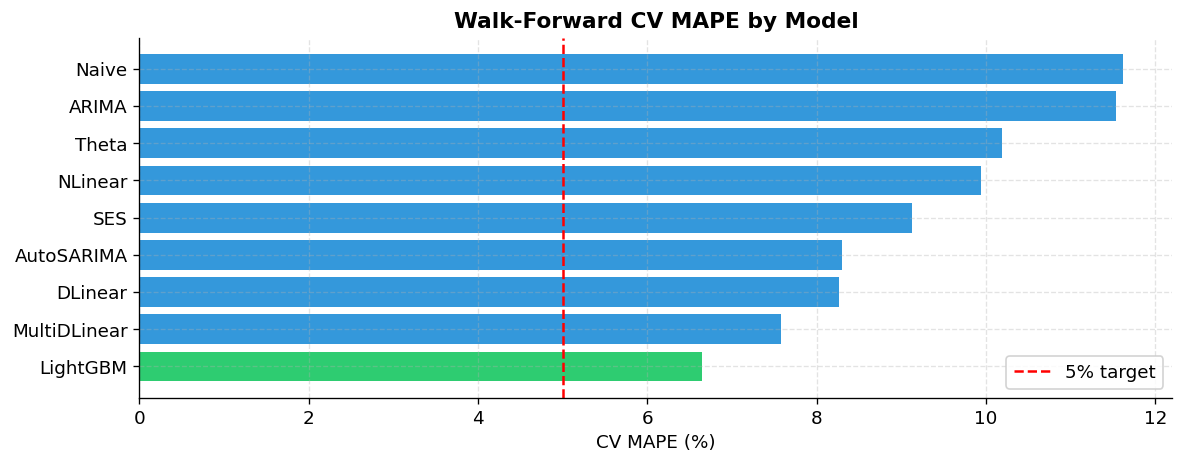

In [77]:
# ── Collect all CV MAPEs ──────────────────────────────────────────────────────
MODEL_REGISTRY = {
    'Naive':       (lambda y: NaiveModel().fit(y),                          mape_naive),
    'SeasonalNaive': None,   # handled separately (uses monthly data)
    'SES':         (lambda y: SESModel().fit(y),                            mape_ses),
    'ARIMA':       (lambda y: ARIMAModel((1,1,0)).fit(y),                   mape_arima),
    'AutoSARIMA':  (lambda y: SARIMAModel(auto=HAS_PMDARIMA).fit(y),        mape_sarima),
    'Theta':       (lambda y: ThetaModel().fit(y),                          mape_theta),
    'NLinear':     (lambda y, lb=best_nl_lb: NLinearModel(lb).fit(y),       nl_grid_results[best_nl_lb]),
    'DLinear':     (lambda y, b=best_dl: DLinearModel(b[0],b[1]).fit(y),    mape_dl),
    'MultiDLinear':(lambda y: MultiDLinearModel((4,8,12,16),5).fit(y),      mape_mdl),
}
if HAS_LGB and mape_lgb is not None:
    MODEL_REGISTRY['LightGBM'] = (lambda y: LightGBMLagModel(12).fit(y), mape_lgb)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = [
    {'Model': name, 'CV MAPE (%)': round(val[1], 2)}
    for name, val in MODEL_REGISTRY.items()
    if val is not None
]
summary_df = pd.DataFrame(summary_rows).sort_values('CV MAPE (%)').reset_index(drop=True)
print('\n── Model CV MAPE Summary ──')
print(summary_df.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors  = ['#2ecc71' if v == summary_df['CV MAPE (%)'].min() else '#3498db'
           for v in summary_df['CV MAPE (%)']]
ax.barh(summary_df['Model'], summary_df['CV MAPE (%)'], color=colors)
ax.set_xlabel('CV MAPE (%)')
ax.set_title('Walk-Forward CV MAPE by Model')
ax.axvline(5, color='red', linestyle='--', linewidth=1.5, label='5% target')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_model_comparison.png', bbox_inches='tight')
plt.show()

### Weighted Ensemble: 80% Weekly Models + 20% Seasonal Naïve

In [78]:
# ── Ensemble candidates (exclude Naive, SeasonalNaive, ARIMA — weakest) ───────
ENSEMBLE_MODELS = {
    k: v for k, v in MODEL_REGISTRY.items()
    if v is not None and k not in ('Naive', 'SeasonalNaive', 'ARIMA')
}

# ── 1/MAPE weights ────────────────────────────────────────────────────────────
raw_inv = {name: 1.0 / max(v[1], 0.01) for name, v in ENSEMBLE_MODELS.items()}
total   = sum(raw_inv.values())
WEIGHTS = {name: raw_inv[name] / total for name in ENSEMBLE_MODELS}

print('Ensemble weights (1/MAPE, normalised):')
for name, w in sorted(WEIGHTS.items(), key=lambda x: -x[1]):
    print(f'  {name:<16}: {w:.4f}  (CV {ENSEMBLE_MODELS[name][1]:.2f}%)')

ALPHA_SN = 0.20   # seasonal naive blend fraction
print(f'\nBlend: {(1-ALPHA_SN)*100:.0f}% ensemble + {ALPHA_SN*100:.0f}% seasonal naïve')

Ensemble weights (1/MAPE, normalised):
  LightGBM        : 0.1810  (CV 6.64%)
  MultiDLinear    : 0.1584  (CV 7.58%)
  DLinear         : 0.1454  (CV 8.26%)
  AutoSARIMA      : 0.1447  (CV 8.30%)
  SES             : 0.1318  (CV 9.12%)
  NLinear         : 0.1208  (CV 9.94%)
  Theta           : 0.1179  (CV 10.19%)

Blend: 80% ensemble + 20% seasonal naïve


In [79]:
def ensemble_forecast_month(ym: tuple,
                             mask: np.ndarray,
                             fws: list, fwe: list) -> tuple:
    """
    Run the full ensemble + seasonal-naïve blend for a single target month.
    Returns (pred_freq, pred_total).
    """
    tr_f = prepare_series(FREQ_RAW[mask], use_log=False)
    tr_t = prepare_series(TOT_RAW[mask],  use_log=True)
    h    = len(fws)

    ens_f = np.zeros(h)
    ens_t = np.zeros(h)

    for name, (fn, _) in ENSEMBLE_MODELS.items():
        pf = np.maximum(fn(tr_f).predict_ar(h), 0)
        pt = exp_transform(fn(tr_t).predict_ar(h))
        ens_f += WEIGHTS[name] * pf
        ens_t += WEIGHTS[name] * pt

    rof = weekly_to_monthly_rollup(fws, fwe, ens_f, {ym})
    rot = weekly_to_monthly_rollup(fws, fwe, ens_t, {ym})
    pf_ens, pt_ens = rof[ym], rot[ym]

    # Seasonal naïve component (uses monthly history up to mask)
    idx    = list(monthly['ym']).index(ym) if ym in list(monthly['ym']) else len(monthly)
    tr_mg  = mg_agg.iloc[:idx]
    pf_sn, pt_sn = seasonal_naive_predict(tr_mg, ym)
    if pf_sn is None:
        pf_sn, pt_sn = pf_ens, pt_ens

    pf = (1 - ALPHA_SN) * pf_ens + ALPHA_SN * pf_sn
    pt = (1 - ALPHA_SN) * pt_ens + ALPHA_SN * pt_sn
    return pf, pt


# ── Backtest the full blend ───────────────────────────────────────────────────
print('Backtest — Weighted Ensemble + Seasonal Naïve blend')
print('=' * 72)
print(f"{'Month':<14}{'GT_Freq':>8}{'Pred_Freq':>10}{'APE_F':>7} | "
      f"{'GT_Sev':>12}{'Pred_Sev':>13}{'APE_S':>7} | {'APE_T':>7}")
print('-' * 84)

blend_results = []
all_e = []

for ym in HELD_OUT:
    ms   = pd.Timestamp(year=ym[0], month=ym[1], day=1)
    me   = ms + pd.offsets.MonthEnd(0)
    mask = WEEKLY_WE_PD < ms
    fws, fwe = get_future_weeks(ms, me)

    pf, pt = ensemble_forecast_month(ym, mask, fws, fwe)
    ps     = pt / pf if pf > 0 else 0
    gt     = MONTHLY_GT[ym]

    ef = abs(gt['frequency']   - pf) / gt['frequency']   * 100
    es = abs(gt['severity']    - ps) / gt['severity']    * 100
    et = abs(gt['total_claim'] - pt) / gt['total_claim'] * 100

    all_e += [ef, es, et]
    blend_results.append({'ym': ym, 'freq_ape': ef, 'sev_ape': es, 'tot_ape': et})

    print(f"{str(ym):<14}{gt['frequency']:>8.0f}{pf:>10.1f}{ef:>6.2f}% | "
          f"{gt['severity']:>12.0f}{ps:>13.0f}{es:>6.2f}% | {et:>6.2f}%")

print('-' * 84)
mape_blend = np.mean(all_e)
print(f"{'OVERALL MAPE':>62}: {mape_blend:.4f}%")

Backtest — Weighted Ensemble + Seasonal Naïve blend
Month          GT_Freq Pred_Freq  APE_F |       GT_Sev     Pred_Sev  APE_S |   APE_T
------------------------------------------------------------------------------------
(2025, 3)          230     253.0 10.01% |     59474961     50554736 15.00% |   6.49%
(2025, 4)          208     224.4  7.86% |     53674271     51978359  3.16% |   4.45%
(2025, 5)          239     230.4  3.58% |     51158139     50856582  0.59% |   4.15%
(2025, 6)          234     235.3  0.55% |     57150085     52050027  8.92% |   8.42%
(2025, 7)          264     237.5 10.03% |     51891009     52266246  0.72% |   9.38%
------------------------------------------------------------------------------------
                                                  OVERALL MAPE: 6.2215%


---
## 10. Final Predictions & Submission

In [80]:
# ── Future weeks: Aug 4 → Dec 31, 2025 ───────────────────────────────────────
last_week_end = weekly['week_end'].max()
cursor        = last_week_end + pd.Timedelta(days=1)
FWS, FWE      = [], []
while cursor <= pd.Timestamp('2025-12-31'):
    FWS.append(cursor)
    FWE.append(min(cursor + pd.Timedelta(days=6), pd.Timestamp('2025-12-31')))
    cursor += pd.Timedelta(days=7)

TARGET_YMS = {(2025, m) for m in range(8, 13)}
H          = len(FWS)
print(f'Future weeks to predict: {H}')

# ── Full-data ensemble ────────────────────────────────────────────────────────
tr_f_full = prepare_series(FREQ_RAW, use_log=False)
tr_t_full = prepare_series(TOT_RAW,  use_log=True)

ens_f_full = np.zeros(H)
ens_t_full = np.zeros(H)

for name, (fn, _) in ENSEMBLE_MODELS.items():
    pf = np.maximum(fn(tr_f_full).predict_ar(H), 0)
    pt = exp_transform(fn(tr_t_full).predict_ar(H))
    ens_f_full += WEIGHTS[name] * pf
    ens_t_full += WEIGHTS[name] * pt
    print(f'  {name}: done')

mo_f_ens = weekly_to_monthly_rollup(FWS, FWE, ens_f_full, TARGET_YMS)
mo_t_ens = weekly_to_monthly_rollup(FWS, FWE, ens_t_full, TARGET_YMS)

# ── Add actual Aug 1-3 (last training week overlaps Aug 1-3) ─────────────────
last_w = weekly.iloc[-1]
mo_f_ens[(2025, 8)] += float(last_w['frequency'])  * 3 / 7
mo_t_ens[(2025, 8)] += float(last_w['total_claim']) * 3 / 7

print('Ensemble predictions done.')

Future weeks to predict: 22
  SES: done
  AutoSARIMA: done
  Theta: done
  NLinear: done
  DLinear: done
  MultiDLinear: done
  LightGBM: done
Ensemble predictions done.


In [81]:
# ── Seasonal naive on full monthly history ────────────────────────────────────
LABEL_MAP = {
    (2025, 8):  '2025_08',
    (2025, 9):  '2025_09',
    (2025, 10): '2025_10',
    (2025, 11): '2025_11',
    (2025, 12): '2025_12',
}

print('\n── Final Predictions (80% ensemble + 20% seasonal naïve) ──')
print(f"{'Month':<10}{'Frequency':>12}{'Severity (IDR)':>20}{'Total Claim (IDR)':>22}")
print('-' * 66)

submission_rows = []

for ym, lbl in sorted(LABEL_MAP.items()):
    pf_ens = mo_f_ens[ym]
    pt_ens = mo_t_ens[ym]

    pf_sn, pt_sn = seasonal_naive_predict(mg_agg, ym)
    if pf_sn is None:
        pf_sn, pt_sn = pf_ens, pt_ens

    f = (1 - ALPHA_SN) * pf_ens + ALPHA_SN * pf_sn
    t = (1 - ALPHA_SN) * pt_ens + ALPHA_SN * pt_sn
    s = t / f if f > 0 else 0

    print(f"{lbl:<10}{f:>12.1f}{s:>20,.0f}{t:>22,.0f}")

    submission_rows += [
        {'id': f'{lbl}_Claim_Frequency', 'value': round(f, 2)},
        {'id': f'{lbl}_Claim_Severity',  'value': round(s, 2)},
        {'id': f'{lbl}_Total_Claim',     'value': round(t, 2)},
    ]

submission = pd.DataFrame(submission_rows)
submission.to_csv(OUTPUT_DIR / 'predictions_2025.csv', index=False)
print(f'\nSaved → {OUTPUT_DIR / "predictions_2025.csv"}')
print(f'CV MAPE (blend backtest): {mape_blend:.4f}%')


── Final Predictions (80% ensemble + 20% seasonal naïve) ──
Month        Frequency      Severity (IDR)     Total Claim (IDR)
------------------------------------------------------------------
2025_08          228.7          51,357,853        11,745,830,311
2025_09          224.3          51,246,797        11,493,693,098
2025_10          244.8          49,271,246        12,059,250,097
2025_11          239.8          49,442,548        11,854,867,832
2025_12          239.6          49,680,091        11,902,191,929

Saved → output\predictions_2025.csv
CV MAPE (blend backtest): 6.2215%


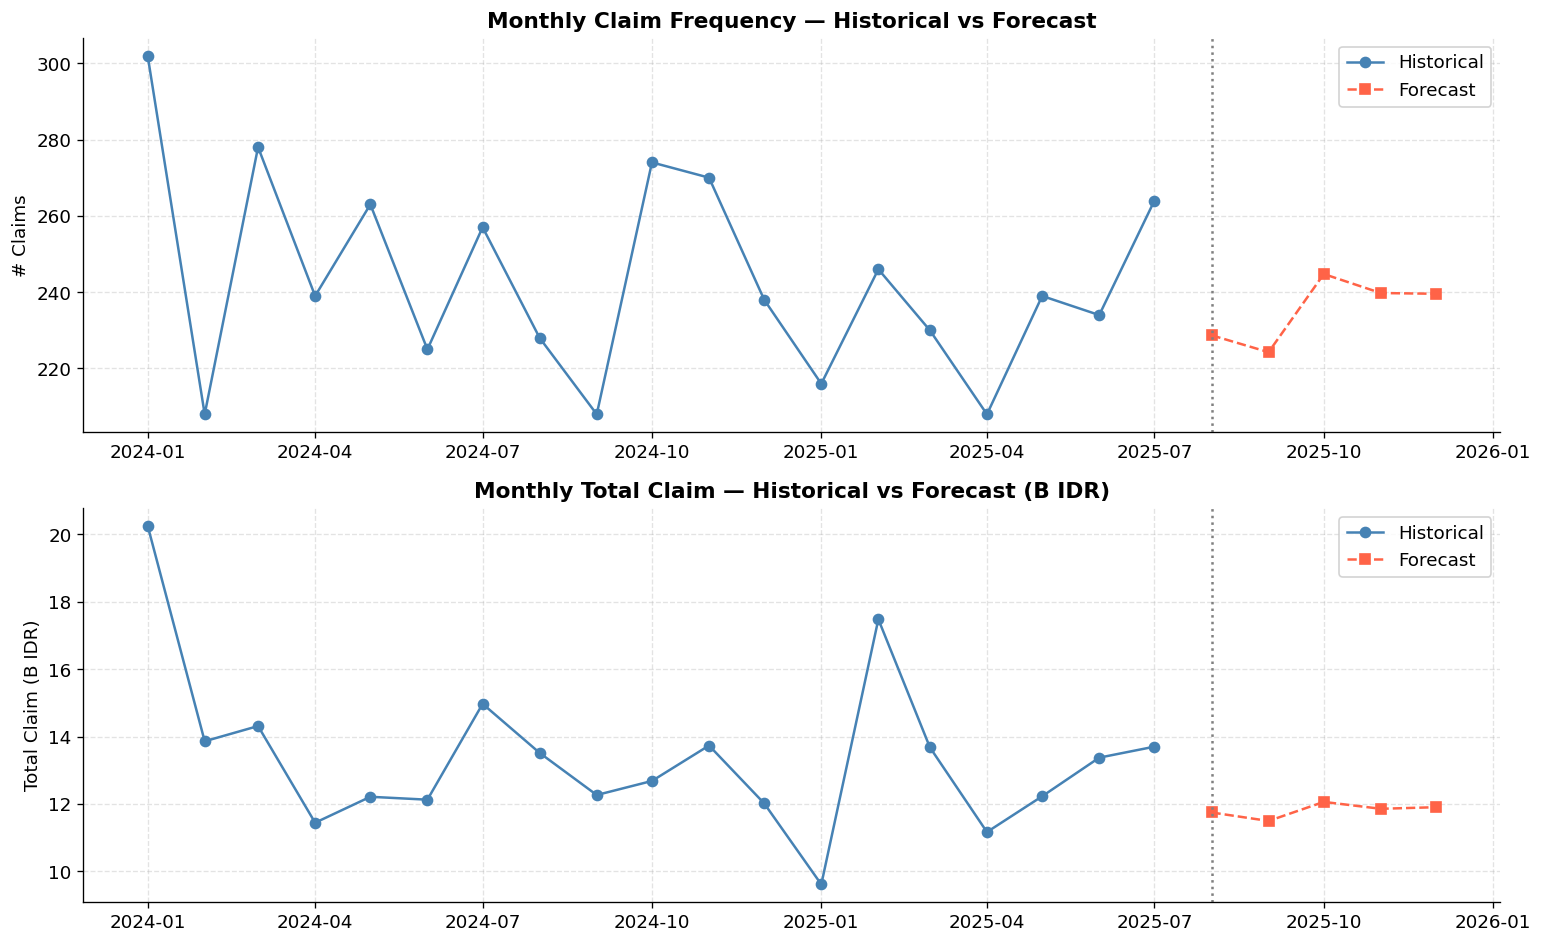


── Final submission preview ──
                     id        value
2025_08_Claim_Frequency 2.287100e+02
 2025_08_Claim_Severity 5.135785e+07
    2025_08_Total_Claim 1.174583e+10
2025_09_Claim_Frequency 2.242800e+02
 2025_09_Claim_Severity 5.124680e+07
    2025_09_Total_Claim 1.149369e+10
2025_10_Claim_Frequency 2.447500e+02
 2025_10_Claim_Severity 4.927125e+07
    2025_10_Total_Claim 1.205925e+10
2025_11_Claim_Frequency 2.397700e+02
 2025_11_Claim_Severity 4.944255e+07
    2025_11_Total_Claim 1.185487e+10
2025_12_Claim_Frequency 2.395800e+02
 2025_12_Claim_Severity 4.968009e+07
    2025_12_Total_Claim 1.190219e+10


In [82]:
# ── Forecast visualisation ────────────────────────────────────────────────────
months_hist = [pd.Timestamp(year=y, month=m, day=1) for y, m in monthly['ym']]
months_pred = [pd.Timestamp(year=y, month=m, day=1) for y, m in sorted(LABEL_MAP.keys())]

pred_freq  = [submission.loc[submission['id'] == f'{lbl}_Claim_Frequency', 'value'].values[0]
              for lbl in [LABEL_MAP[k] for k in sorted(LABEL_MAP)]]
pred_tot   = [submission.loc[submission['id'] == f'{lbl}_Total_Claim',     'value'].values[0]
              for lbl in [LABEL_MAP[k] for k in sorted(LABEL_MAP)]]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Frequency
axes[0].plot(months_hist, monthly['frequency'], marker='o', color='steelblue', label='Historical')
axes[0].plot(months_pred, pred_freq, marker='s', linestyle='--', color='tomato', label='Forecast')
axes[0].set_title('Monthly Claim Frequency — Historical vs Forecast')
axes[0].set_ylabel('# Claims')
axes[0].legend()

# Total Claim
axes[1].plot(months_hist, monthly['total_claim'] / 1e9, marker='o', color='steelblue', label='Historical')
axes[1].plot(months_pred, [v / 1e9 for v in pred_tot], marker='s', linestyle='--', color='tomato', label='Forecast')
axes[1].set_title('Monthly Total Claim — Historical vs Forecast (B IDR)')
axes[1].set_ylabel('Total Claim (B IDR)')
axes[1].legend()

for ax in axes:
    ax.axvline(pd.Timestamp('2025-08-01'), color='gray', linestyle=':', linewidth=1.5, label='Forecast start')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_final_forecast.png', bbox_inches='tight')
plt.show()

print('\n── Final submission preview ──')
print(submission.to_string(index=False))

---
## 11. Extended Forecast — Full 2026

Predictions are extended through **December 2026** (17 months total: Aug 2025 – Dec 2026).

For **2026 months**, the seasonal-naïve component uses the 2025 predicted values as the prior-year baseline, scaled by the same YoY median ratio derived from 2024→2025.

In [83]:
# ── Extended future weeks: Aug 4, 2025 → Dec 31, 2026 ────────────────────────
END_DATE_EXTENDED = pd.Timestamp('2026-12-31')
cursor  = last_week_end + pd.Timedelta(days=1)
FWS_EXT, FWE_EXT = [], []
while cursor <= END_DATE_EXTENDED:
    FWS_EXT.append(cursor)
    FWE_EXT.append(min(cursor + pd.Timedelta(days=6), END_DATE_EXTENDED))
    cursor += pd.Timedelta(days=7)
H_EXT = len(FWS_EXT)

TARGET_YMS_EXT = {
    (y, m)
    for y in [2025, 2026]
    for m in range(1, 13)
    if (y, m) >= (2025, 8)
}

print(f'Extended horizon: {H_EXT} future weeks')
print(f'Target months   : {len(TARGET_YMS_EXT)}')

# ── Re-run ensemble on extended horizon ──────────────────────────────────────
tr_f_full = prepare_series(FREQ_RAW, use_log=False)
tr_t_full = prepare_series(TOT_RAW,  use_log=True)

ens_f_ext = np.zeros(H_EXT)
ens_t_ext = np.zeros(H_EXT)

for name, (fn, _) in ENSEMBLE_MODELS.items():
    pf = np.maximum(fn(tr_f_full).predict_ar(H_EXT), 0)
    pt = exp_transform(fn(tr_t_full).predict_ar(H_EXT))
    ens_f_ext += WEIGHTS[name] * pf
    ens_t_ext += WEIGHTS[name] * pt
    print(f'  {name}: done')

mo_f_ens_ext = weekly_to_monthly_rollup(FWS_EXT, FWE_EXT, ens_f_ext, TARGET_YMS_EXT)
mo_t_ens_ext = weekly_to_monthly_rollup(FWS_EXT, FWE_EXT, ens_t_ext, TARGET_YMS_EXT)

# Add actual Aug 1-3 to Aug 2025
last_w = weekly.iloc[-1]
mo_f_ens_ext[(2025, 8)] += float(last_w['frequency'])  * 3 / 7
mo_t_ens_ext[(2025, 8)] += float(last_w['total_claim']) * 3 / 7

print('\nEnsemble rollup complete.')

Extended horizon: 74 future weeks
Target months   : 17
  SES: done
  AutoSARIMA: done
  Theta: done
  NLinear: done
  DLinear: done
  MultiDLinear: done
  LightGBM: done

Ensemble rollup complete.


In [84]:
# ── Build combined monthly table for 2026 seasonal-naïve anchor ──────────────
# Step 1: generate 2025 blend predictions
mg_combined = mg_agg.copy()
preds_2025  = {}

for ym in sorted([(2025, m) for m in range(8, 13)]):
    pf_ens = mo_f_ens_ext[ym]
    pt_ens = mo_t_ens_ext[ym]
    pf_sn, pt_sn = seasonal_naive_predict(mg_combined, ym)
    if pf_sn is None:
        pf_sn, pt_sn = pf_ens, pt_ens
    f = (1 - ALPHA_SN) * pf_ens + ALPHA_SN * pf_sn
    t = (1 - ALPHA_SN) * pt_ens + ALPHA_SN * pt_sn
    preds_2025[ym] = (f, t)
    # Append to combined table so 2026 SN can reference 2025 predictions
    mg_combined = pd.concat([
        mg_combined,
        pd.DataFrame({'ym': [ym], 'freq': [f], 'tot': [t]})
    ], ignore_index=True)

# Step 2: generate 2026 blend predictions
preds_2026 = {}
for ym in sorted([(2026, m) for m in range(1, 13)]):
    pf_ens = mo_f_ens_ext.get(ym, 0)
    pt_ens = mo_t_ens_ext.get(ym, 0)
    pf_sn, pt_sn = seasonal_naive_predict(mg_combined, ym)
    if pf_sn is None:
        pf_sn, pt_sn = pf_ens, pt_ens
    f = (1 - ALPHA_SN) * pf_ens + ALPHA_SN * pf_sn
    t = (1 - ALPHA_SN) * pt_ens + ALPHA_SN * pt_sn
    preds_2026[ym] = (f, t)

# ── Merge all predictions ─────────────────────────────────────────────────────
ALL_PREDS = {**preds_2025, **preds_2026}

print(f"{'Month':<14}{'Frequency':>10}{'Severity (M)':>14}{'Total (B)':>12}")
print('-' * 52)
for ym in sorted(ALL_PREDS):
    f, t = ALL_PREDS[ym]
    s = t / f if f > 0 else 0
    print(f"{str(ym):<14}{f:>10.1f}{s/1e6:>13.1f}M{t/1e9:>11.2f}B")

Month          Frequency  Severity (M)   Total (B)
----------------------------------------------------
(2025, 8)          228.7         51.4M      11.75B
(2025, 9)          226.2         50.7M      11.47B
(2025, 10)         247.3         48.4M      11.98B
(2025, 11)         239.1         48.9M      11.69B
(2025, 12)         238.7         49.0M      11.70B
(2026, 1)          232.7         48.8M      11.37B
(2026, 2)          220.6         53.7M      11.84B
(2026, 3)          233.7         51.7M      12.08B
(2026, 4)          219.6         51.1M      11.23B
(2026, 5)          235.0         49.3M      11.59B
(2026, 6)          229.1         51.2M      11.73B
(2026, 7)          240.2         49.9M      11.99B
(2026, 8)          235.0         50.4M      11.86B
(2026, 9)          225.0         48.9M      11.00B
(2026, 10)         236.1         49.6M      11.70B
(2026, 11)         227.9         49.2M      11.22B
(2026, 12)         232.9         49.4M      11.51B


In [85]:
# ── Build submission CSV ──────────────────────────────────────────────────────
submission_rows_ext = []
for ym in sorted(ALL_PREDS):
    f, t = ALL_PREDS[ym]
    s    = t / f if f > 0 else 0
    lbl  = f'{ym[0]}_{str(ym[1]).zfill(2)}'
    submission_rows_ext += [
        {'id': f'{lbl}_Claim_Frequency', 'value': round(f, 2)},
        {'id': f'{lbl}_Claim_Severity',  'value': round(s, 2)},
        {'id': f'{lbl}_Total_Claim',     'value': round(t, 2)},
    ]

submission_ext = pd.DataFrame(submission_rows_ext)
submission_ext.to_csv(OUTPUT_DIR / 'predictions_2025_2026.csv', index=False)
print(f'Saved {len(submission_ext)} rows → output/predictions_2025_2026.csv')
display(submission_ext)

Saved 51 rows → output/predictions_2025_2026.csv


,id,value
0,2025_08_Claim_Frequency,2.287100e+02
1,2025_08_Claim_Severity,5.135785e+07
2,2025_08_Total_Claim,1.174583e+10
3,2025_09_Claim_Frequency,2.262400e+02
4,2025_09_Claim_Severity,5.069404e+07
5,2025_09_Total_Claim,1.146920e+10
6,2025_10_Claim_Frequency,2.473400e+02
7,2025_10_Claim_Severity,4.841751e+07
8,2025_10_Total_Claim,1.197546e+10
9,2025_11_Claim_Frequency,2.391200e+02


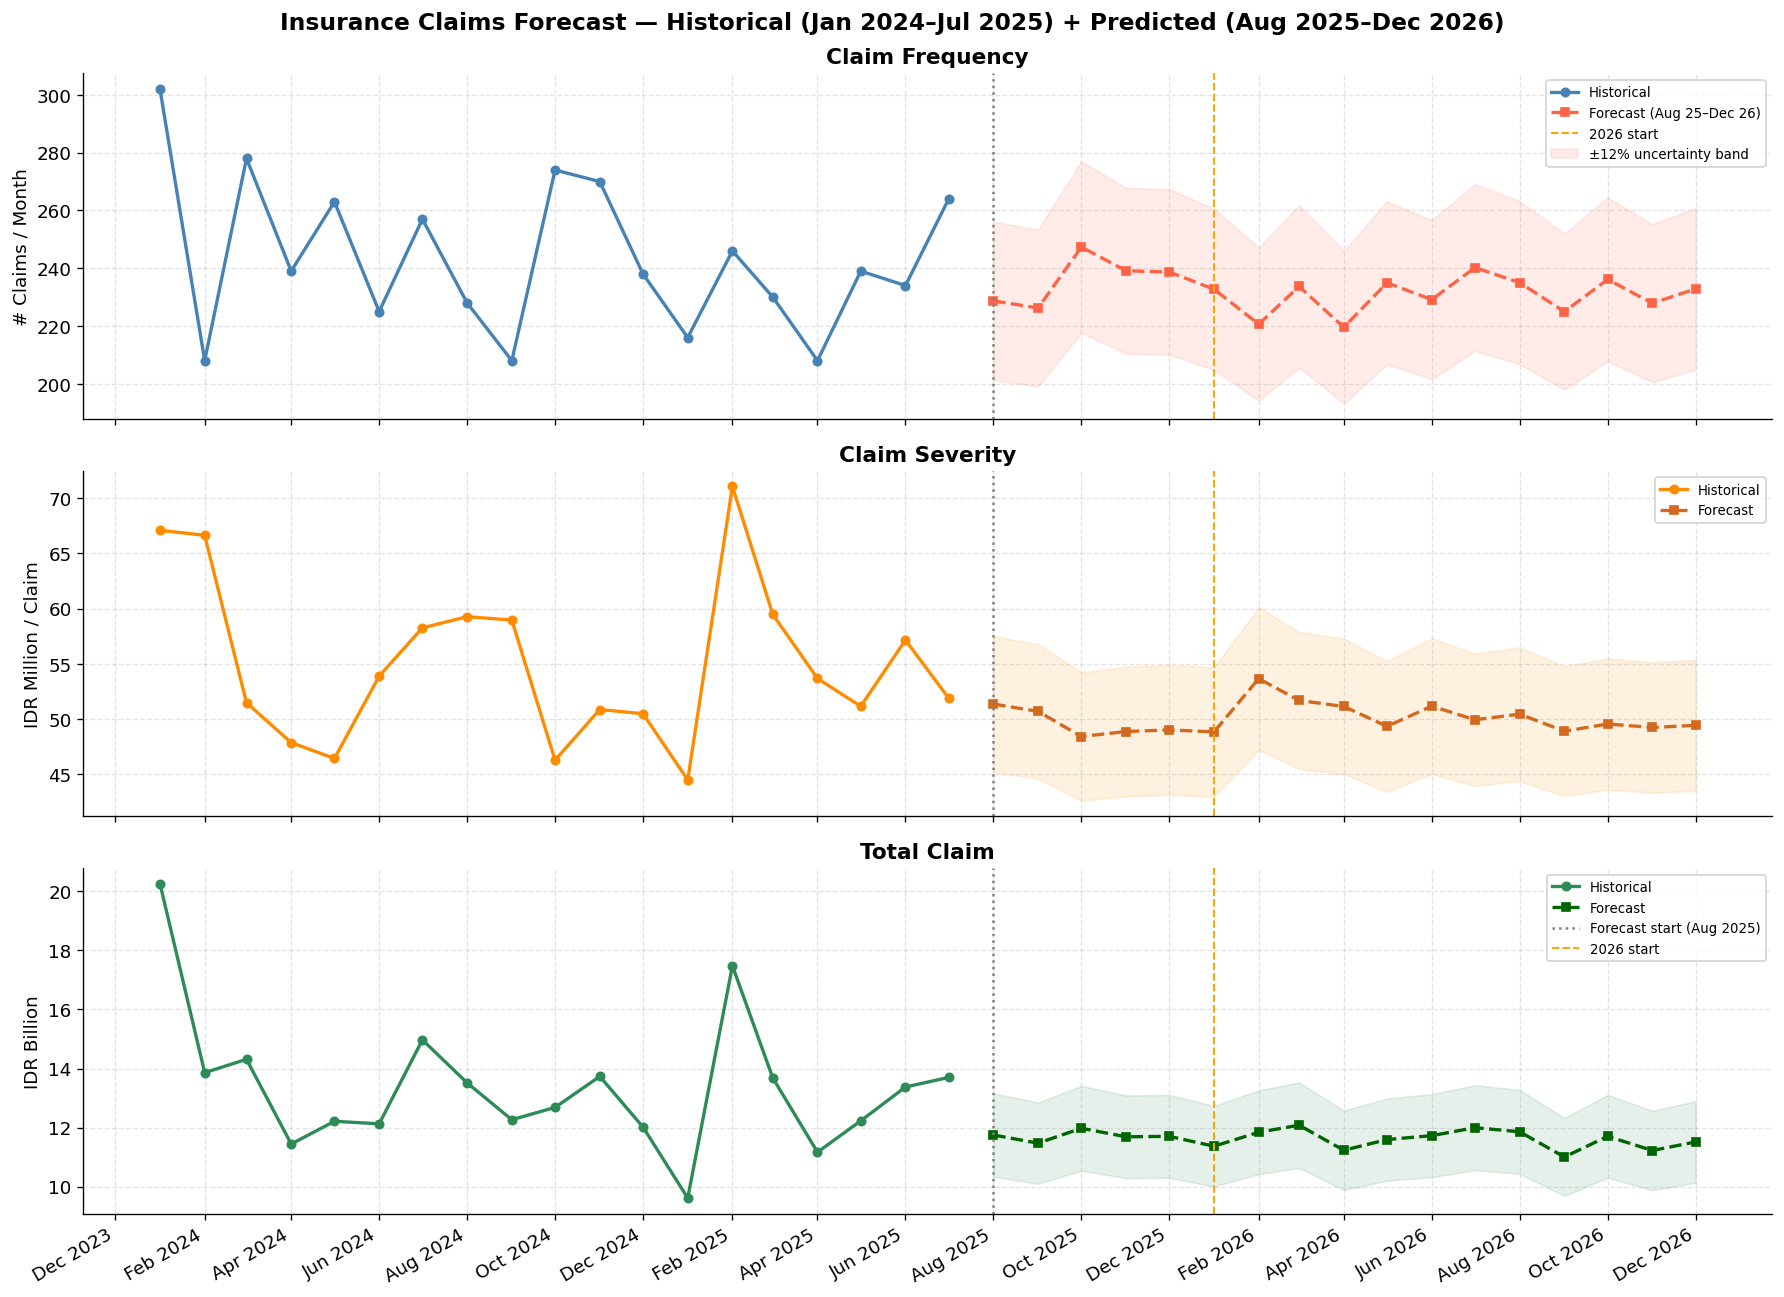

Saved → output/fig_forecast_2025_2026.png


In [86]:
# ── Forecast visualisation: Historical + Aug 2025 – Dec 2026 ─────────────────
months_hist = [pd.Timestamp(year=y, month=m, day=1) for y, m in monthly['ym']]
months_pred = [pd.Timestamp(year=ym[0], month=ym[1], day=1)
               for ym in sorted(ALL_PREDS)]

freq_pred  = [ALL_PREDS[ym][0] for ym in sorted(ALL_PREDS)]
total_pred = [ALL_PREDS[ym][1] for ym in sorted(ALL_PREDS)]
sev_pred   = [ALL_PREDS[ym][1] / ALL_PREDS[ym][0]
              if ALL_PREDS[ym][0] > 0 else 0
              for ym in sorted(ALL_PREDS)]

# Shade 2025 predictions differently from 2026
split_date   = pd.Timestamp('2026-01-01')
forecast_start = pd.Timestamp('2025-08-01')

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle('Insurance Claims Forecast — Historical (Jan 2024–Jul 2025)'
             ' + Predicted (Aug 2025–Dec 2026)',
             fontsize=14, fontweight='bold')

# ── Panel 1: Frequency ───────────────────────────────────────────────────────
axes[0].plot(months_hist, monthly['frequency'],
             marker='o', ms=5, lw=2, color='steelblue', label='Historical')
axes[0].plot(months_pred, freq_pred,
             marker='s', ms=5, lw=2, linestyle='--', color='tomato',
             label='Forecast (Aug 25–Dec 26)')
axes[0].axvline(forecast_start, color='gray', lw=1.5, linestyle=':')
axes[0].axvline(split_date,     color='orange', lw=1.2, linestyle='--',
                label='2026 start')
axes[0].fill_between(months_pred,
                     [v * 0.88 for v in freq_pred],
                     [v * 1.12 for v in freq_pred],
                     alpha=0.12, color='tomato', label='±12% uncertainty band')
axes[0].set_ylabel('# Claims / Month')
axes[0].set_title('Claim Frequency')
axes[0].legend(fontsize=8, loc='upper right')

# ── Panel 2: Severity ────────────────────────────────────────────────────────
axes[1].plot(months_hist, monthly['severity'] / 1e6,
             marker='o', ms=5, lw=2, color='darkorange', label='Historical')
axes[1].plot(months_pred, [v / 1e6 for v in sev_pred],
             marker='s', ms=5, lw=2, linestyle='--', color='chocolate',
             label='Forecast')
axes[1].axvline(forecast_start, color='gray', lw=1.5, linestyle=':')
axes[1].axvline(split_date,     color='orange', lw=1.2, linestyle='--')
axes[1].fill_between(months_pred,
                     [v / 1e6 * 0.88 for v in sev_pred],
                     [v / 1e6 * 1.12 for v in sev_pred],
                     alpha=0.12, color='darkorange')
axes[1].set_ylabel('IDR Million / Claim')
axes[1].set_title('Claim Severity')
axes[1].legend(fontsize=8, loc='upper right')

# ── Panel 3: Total Claim ─────────────────────────────────────────────────────
axes[2].plot(months_hist, monthly['total_claim'] / 1e9,
             marker='o', ms=5, lw=2, color='seagreen', label='Historical')
axes[2].plot(months_pred, [v / 1e9 for v in total_pred],
             marker='s', ms=5, lw=2, linestyle='--', color='darkgreen',
             label='Forecast')
axes[2].axvline(forecast_start, color='gray', lw=1.5, linestyle=':',
                label='Forecast start (Aug 2025)')
axes[2].axvline(split_date,     color='orange', lw=1.2, linestyle='--',
                label='2026 start')
axes[2].fill_between(months_pred,
                     [v / 1e9 * 0.88 for v in total_pred],
                     [v / 1e9 * 1.12 for v in total_pred],
                     alpha=0.12, color='seagreen')
axes[2].set_ylabel('IDR Billion')
axes[2].set_title('Total Claim')
axes[2].legend(fontsize=8, loc='upper right')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_forecast_2025_2026.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → output/fig_forecast_2025_2026.png')